In [1]:
land = gpd.read_parquet("data/raw/dallas_land_use.parquet")

NameError: name 'gpd' is not defined

In [2]:
import geopandas as gpd

In [3]:

land = gpd.read_parquet("data/raw/dallas_land_use.parquet")

FileNotFoundError: [WinError 3] Failed to open local file 'data/raw/dallas_land_use.parquet'. Detail: [Windows error 3] The system cannot find the path specified.


In [4]:
import os
print(os.getcwd())

c:\Users\gunja\AppData\Local\Programs\Microsoft VS Code


In [5]:
import os
print(os.listdir())

['88e44fa0e0', 'bin', 'Code.exe', 'Code.VisualElementsManifest.xml', 'unins000.dat', 'unins000.exe', 'unins000.msg']


In [6]:
import os

for root, dirs, files in os.walk(r"C:\Users\gunja"):
    for file in files:
        if file.endswith(".parquet"):
            print(os.path.join(root, file))

C:\Users\gunja\dallas_buildings.parquet
C:\Users\gunja\dallas_landuse.parquet


KeyboardInterrupt: 

In [7]:
land = gpd.read_parquet(
    r"C:\Users\gunja\dallas_landuse.parquet"
)

In [8]:
print(land.shape)

(379, 12)


In [9]:
print(land.columns.tolist())

['id', 'geometry', 'sources', 'names', 'level', 'wikidata', 'source_tags', 'subtype', 'class', 'elevation', 'surface', 'version']


In [10]:
import os

for root, dirs, files in os.walk(r"C:\Users\gunja"):
    for file in files:
        if file.endswith(".parquet"):
            print(os.path.join(root, file))

C:\Users\gunja\dallas_buildings.parquet
C:\Users\gunja\dallas_landuse.parquet


KeyboardInterrupt: 

In [11]:
import geopandas as gpd

land = gpd.read_parquet(r"C:\Users\gunja\dallas_landuse.parquet")

print(land.shape)

(379, 12)


In [12]:
print(land.columns.tolist())

['id', 'geometry', 'sources', 'names', 'level', 'wikidata', 'source_tags', 'subtype', 'class', 'elevation', 'surface', 'version']


In [13]:
print(land.head())

                                     id  \
0  ec8f9a37-3825-3d11-811b-1372bdf10f06   
1  3c4289e8-1bb7-30cc-8bb8-786d95089610   
2  0cb48b56-759a-3246-b7be-1617b639ba7b   
3  947df544-e36e-33e5-877a-0ed46f28c4b1   
4  704314ea-00dd-326f-96d2-8e90c63c0144   

                                            geometry  \
0  POLYGON ((-96.89685 32.82088, -96.89909 32.823...   
1  POLYGON ((-96.81402 32.77337, -96.81396 32.773...   
2  POLYGON ((-96.81526 32.77388, -96.81578 32.775...   
3  POLYGON ((-96.81363 32.77809, -96.81365 32.778...   
4  POLYGON ((-96.81374 32.77917, -96.81376 32.779...   

                                             sources  \
0  [{'property': '', 'dataset': 'OpenStreetMap', ...   
1  [{'property': '', 'dataset': 'OpenStreetMap', ...   
2  [{'property': '', 'dataset': 'OpenStreetMap', ...   
3  [{'property': '', 'dataset': 'OpenStreetMap', ...   
4  [{'property': '', 'dataset': 'OpenStreetMap', ...   

                                               names  level wikidat

In [14]:
print(land.dtypes)

id                  str
geometry       geometry
sources          object
names            object
level           float64
wikidata            str
source_tags      object
subtype             str
class               str
elevation       float64
surface             str
version           int32
dtype: object


In [15]:
print(land["class"].value_counts(dropna=False))

class
grass           115
residential      48
commercial       47
park             46
retail           21
pedestrian       19
railway          16
brownfield       13
pitch             8
playground        8
construction      8
garden            6
dog_park          6
flowerbed         5
school            3
college           2
university        2
religious         2
protected         1
hospital          1
greenfield        1
cemetery          1
Name: count, dtype: int64


In [16]:
print(land["subtype"].value_counts(dropna=False))

subtype
managed           115
developed          81
park               52
residential        48
pedestrian         19
recreation         16
transportation     16
horticulture       11
construction        9
education           7
religious           2
protected           1
medical             1
cemetery            1
Name: count, dtype: int64


In [17]:
parking = land[
    land["class"].astype(str).str.contains("parking", case=False, na=False) |
    land["subtype"].astype(str).str.contains("parking", case=False, na=False)
]

print(parking[["class", "subtype"]].value_counts())

Series([], Name: count, dtype: int64)


In [18]:
parking = land[
    land["class"].astype(str).str.contains("parking", case=False, na=False) |
    land["subtype"].astype(str).str.contains("parking", case=False, na=False)
].copy()

In [19]:
print(len(parking))

0


In [20]:
parking.to_file(
    r"C:\Users\gunja\dallas_parking.gpkg",
    layer="parking_lots",
    driver="GPKG"
)

c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


In [21]:
import os
import pyogrio

os.environ["GDAL_DATA"] = os.path.join(
    os.environ["CONDA_PREFIX"],
    "Library",
    "share",
    "gdal"
)

print("GDAL_DATA =", os.environ["GDAL_DATA"])
print("Exists:", os.path.exists(os.environ["GDAL_DATA"]))

GDAL_DATA = C:\Users\gunja\miniconda3\envs\geo_env\Library\share\gdal
Exists: True


In [22]:
parking.to_file(
    r"C:\Users\gunja\dallas_parking.gpkg",
    layer="parking_lots",
    driver="GPKG"
)

In [23]:
import os

path = r"C:\Users\gunja\dallas_parking.gpkg"

print("File exists:", os.path.exists(path))

if os.path.exists(path):
    print("File size:", os.path.getsize(path), "bytes")

File exists: True
File size: 98304 bytes


In [24]:
print("Number of features:", len(parking))
print("Geometry types:")
print(parking.geometry.geom_type.value_counts())

Number of features: 0
Geometry types:
Series([], Name: count, dtype: int64)


In [25]:
print(land["class"].value_counts(dropna=False))

class
grass           115
residential      48
commercial       47
park             46
retail           21
pedestrian       19
railway          16
brownfield       13
pitch             8
playground        8
construction      8
garden            6
dog_park          6
flowerbed         5
school            3
college           2
university        2
religious         2
protected         1
hospital          1
greenfield        1
cemetery          1
Name: count, dtype: int64


In [26]:
print(land["subtype"].value_counts(dropna=False))

subtype
managed           115
developed          81
park               52
residential        48
pedestrian         19
recreation         16
transportation     16
horticulture       11
construction        9
education           7
religious           2
protected           1
medical             1
cemetery            1
Name: count, dtype: int64


In [27]:
print(land["surface"].value_counts(dropna=False))

surface
NaN                 368
paving_stones         5
recreation_paved      4
paved                 2
Name: count, dtype: int64


In [2]:
parking_candidates = land[
    land["class"].isin(["commercial", "retail", "transportation"])
].copy()

print(parking_candidates[["class", "subtype", "surface", "names"]].to_string())

NameError: name 'land' is not defined

In [3]:
import geopandas as gpd

land = gpd.read_parquet(
    r"C:\Users\gunja\dallas_landuse.parquet"
)

print("Loaded:", len(land), "features")


Loaded: 379 features


In [4]:
parking_candidates = land[
    land["class"].isin(["commercial", "retail", "transportation"])
].copy()

print(
    parking_candidates[
        ["class", "subtype", "surface", "names"]
    ].to_string()
)

          class    subtype surface                                                          names
2    commercial  developed     NaN    {'primary': 'East Overlook', 'common': None, 'rules': None}
7        retail  developed     NaN                                                           None
9    commercial  developed     NaN                                                           None
10   commercial  developed     NaN                                                           None
11   commercial  developed     NaN                                                           None
24       retail  developed     NaN                                                           None
25       retail  developed     NaN                                                           None
39       retail  developed     NaN                                                           None
44       retail  developed     NaN                                                           None
56       retail  dev

In [5]:
print(
    land[land["class"] == "transportation"]
    [["class", "subtype", "surface", "names"]]
    .to_string()
)

Empty DataFrame
Columns: [class, subtype, surface, names]
Index: []


In [6]:
buildings = gpd.read_parquet(
    r"C:\Users\gunja\dallas_buildings.parquet"
)

print("Buildings:", len(buildings))
print(buildings.columns.tolist())

Buildings: 1785
['id', 'names', 'sources', 'level', 'height', 'min_height', 'is_underground', 'num_floors', 'num_floors_underground', 'min_floor', 'subtype', 'class', 'facade_color', 'facade_material', 'roof_material', 'roof_shape', 'roof_direction', 'roof_orientation', 'roof_color', 'roof_height', 'geometry', 'has_parts', 'version']


In [7]:
print(buildings.geometry.geom_type.value_counts())
print(buildings.crs)

Polygon    1785
Name: count, dtype: int64
OGC:CRS84


Matplotlib is building the font cache; this may take a moment.


<Axes: >

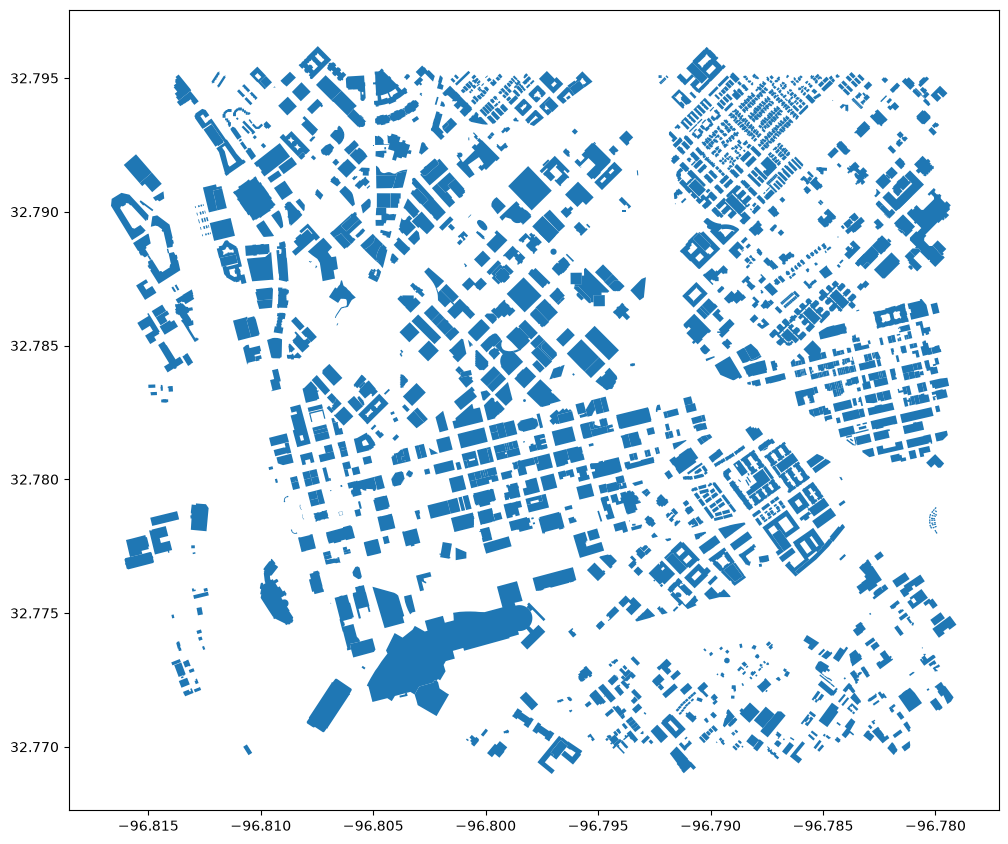

In [8]:
buildings.plot(figsize=(12, 12))

In [9]:
buildings_m = buildings.to_crs("EPSG:32614")

print(buildings_m.crs)

EPSG:32614


In [10]:
buildings_m["area_m2"] = buildings_m.geometry.area

print(buildings_m["area_m2"].describe())

count      1785.000000
mean       1326.916316
std        3691.918817
min           7.855054
25%         188.094798
50%         430.669131
75%        1516.601675
max      131964.011786
Name: area_m2, dtype: float64


In [11]:
print(
    buildings_m[["area_m2"]]
    .sort_values("area_m2", ascending=False)
    .head(20)
)

            area_m2
22    131964.011786
1781   23568.333002
26     19197.873400
258    17646.618000
191    17521.327275
614    16542.233180
23     13779.685841
21     12383.626233
285    11721.999821
414    11458.933524
635    11114.018568
338    11043.831429
477    10971.289912
259    10806.738540
524    10551.245644
1477    9990.453483
1317    9672.831545
603     9659.428420
236     9488.665070
559     9401.954944


In [12]:
print(buildings.total_bounds)

[-96.8166593  32.7689828 -96.7790675  32.7961922]


<Axes: >

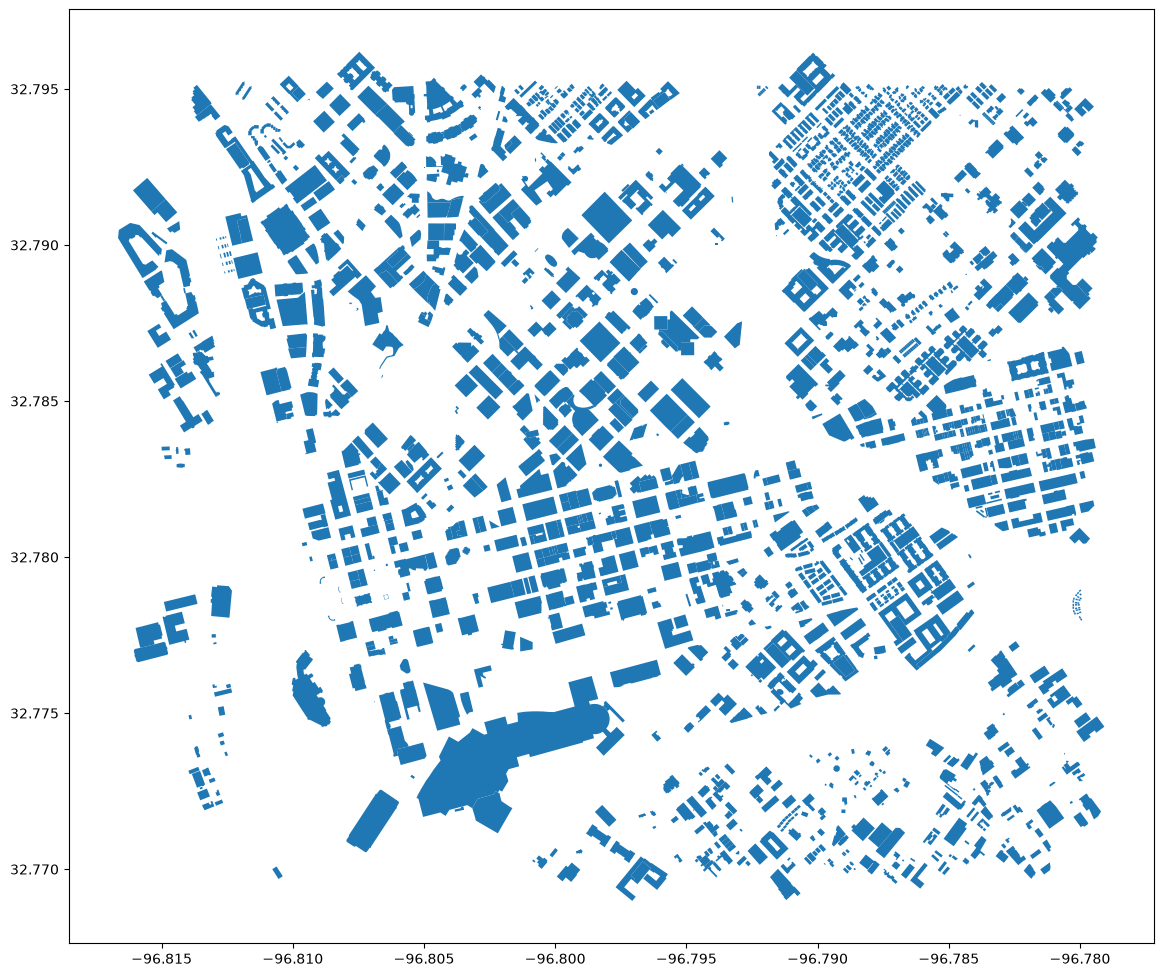

In [13]:
buildings.plot(figsize=(14, 14))

In [14]:
print(buildings.total_bounds)

[-96.8166593  32.7689828 -96.7790675  32.7961922]


In [15]:
from shapely.geometry import box

study_area = gpd.GeoDataFrame(
    geometry=[box(*buildings.total_bounds)],
    crs=buildings.crs
)

print(study_area)

                                            geometry
0  POLYGON ((-96.77907 32.76898, -96.77907 32.796...


In [16]:
study_area_m = study_area.to_crs("EPSG:32614")

print(study_area_m.crs)

EPSG:32614


In [17]:
print(
    "Study area:",
    round(study_area_m.geometry.area.iloc[0] / 1_000_000, 2),
    "km²"
)

Study area: 10.63 km²


In [18]:
building_union = buildings_m.geometry.union_all()

print("Combined building geometry created.")

Combined building geometry created.


In [19]:
open_space = study_area_m.geometry.iloc[0].difference(building_union)

print("Open space created.")

Open space created.


In [20]:
open_spaces = gpd.GeoDataFrame(
    geometry=[open_space],
    crs=study_area_m.crs
)

print(open_spaces.geometry.geom_type)

0    MultiPolygon
dtype: str


In [21]:
open_spaces = open_spaces.explode(index_parts=False).reset_index(drop=True)

print("Open areas:", len(open_spaces))

Open areas: 84


In [22]:
open_spaces["area_m2"] = open_spaces.geometry.area

print(open_spaces["area_m2"].describe())

count    8.400000e+01
mean     9.850450e+04
std      8.987135e+05
min      2.327364e-02
25%      9.977331e+01
50%      2.864831e+02
75%      6.826843e+02
max      8.237291e+06
Name: area_m2, dtype: float64


In [23]:
print(
    open_spaces[["area_m2"]]
    .sort_values("area_m2", ascending=False)
    .head(20)
)

         area_m2
0   8.237291e+06
62  2.215797e+03
4   1.905146e+03
57  1.493494e+03
36  1.415082e+03
53  1.406228e+03
52  1.224672e+03
59  1.209984e+03
81  1.064863e+03
54  1.016715e+03
64  9.148806e+02
38  9.079227e+02
61  8.282162e+02
11  8.080363e+02
82  8.016548e+02
51  7.906010e+02
35  7.720076e+02
3   7.670035e+02
56  7.431197e+02
30  7.216462e+02


In [24]:
land_m = land.to_crs("EPSG:32614")

print(land_m.crs)

EPSG:32614


<Axes: >

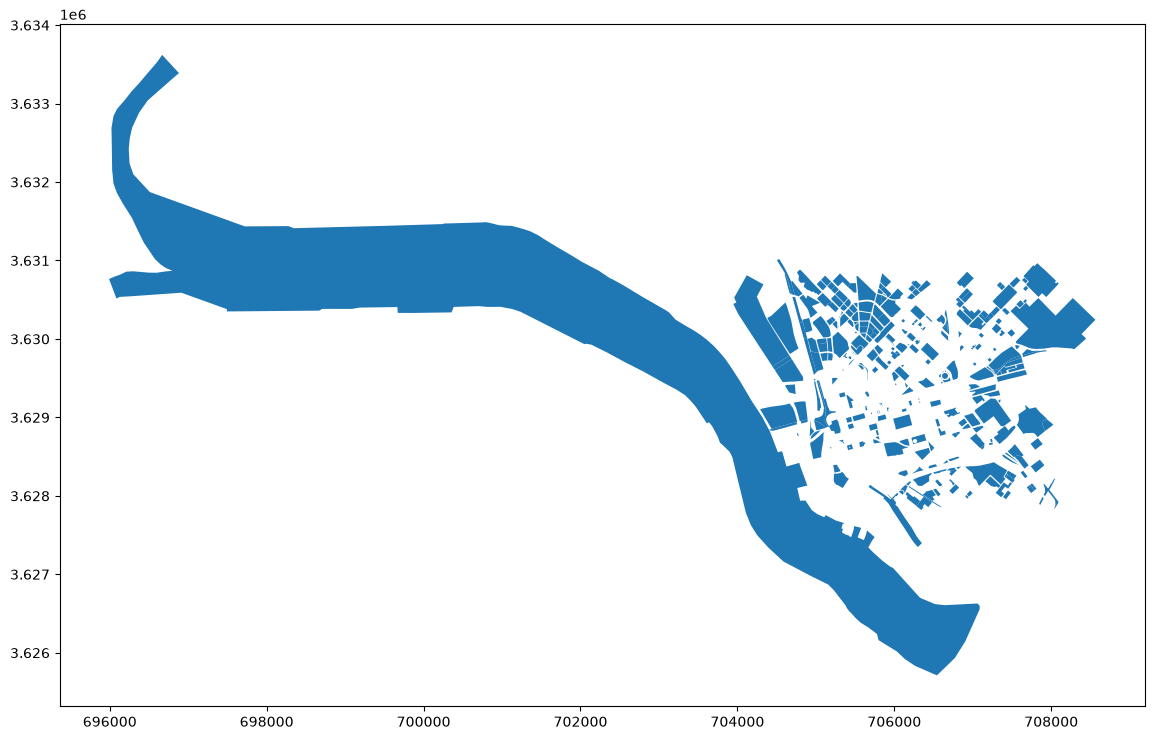

In [25]:
land_m.plot(figsize=(14, 14))

In [26]:
open_with_land = gpd.sjoin(
    open_spaces,
    land_m[["class", "subtype", "geometry"]],
    how="left",
    predicate="intersects"
)

print(
    open_with_land[
        ["area_m2", "class", "subtype"]
    ]
    .sort_values("area_m2", ascending=False)
    .head(30)
    .to_string(index=False)
)

     area_m2       class        subtype
8.237291e+06       grass        managed
8.237291e+06  commercial      developed
8.237291e+06       grass        managed
8.237291e+06      garden   horticulture
8.237291e+06       grass        managed
8.237291e+06  playground     recreation
8.237291e+06       grass        managed
8.237291e+06  pedestrian     pedestrian
8.237291e+06  commercial      developed
8.237291e+06  pedestrian     pedestrian
8.237291e+06  pedestrian     pedestrian
8.237291e+06 residential    residential
8.237291e+06       grass        managed
8.237291e+06  commercial      developed
8.237291e+06 residential    residential
8.237291e+06  commercial      developed
8.237291e+06     railway transportation
8.237291e+06 residential    residential
8.237291e+06 residential    residential
8.237291e+06  commercial      developed
8.237291e+06       grass        managed
8.237291e+06   protected      protected
8.237291e+06       grass        managed
8.237291e+06       grass        managed


In [27]:
open_candidates = open_spaces[
    (open_spaces["area_m2"] >= 1000) &
    (open_spaces["area_m2"] <= 20000)
].copy()

print("Candidate open areas:", len(open_candidates))
print(
    open_candidates[["area_m2"]]
    .sort_values("area_m2", ascending=False)
)

Candidate open areas: 9
        area_m2
62  2215.796873
4   1905.146460
57  1493.494426
36  1415.081604
53  1406.228132
52  1224.672028
59  1209.983691
81  1064.863486
54  1016.714662


<Axes: >

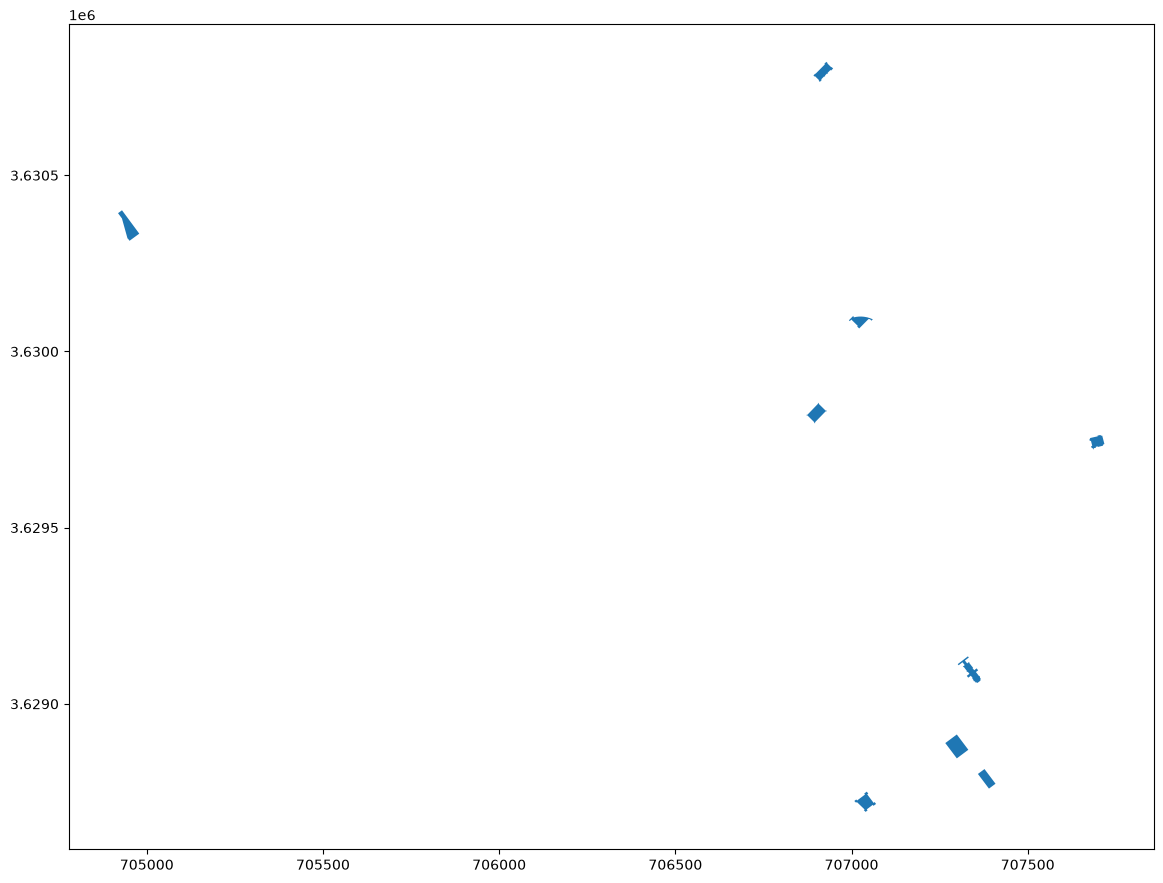

In [28]:
open_candidates.plot(figsize=(14, 14))

In [29]:
candidate_land = gpd.sjoin(
    open_candidates,
    land_m[["class", "subtype", "geometry"]],
    how="left",
    predicate="intersects"
)

print(
    candidate_land[
        ["area_m2", "class", "subtype"]
    ]
    .sort_values("area_m2", ascending=False)
    .to_string(index=False)
)

    area_m2       class     subtype
2215.796873         NaN         NaN
1905.146460 residential residential
1493.494426 residential residential
1415.081604         NaN         NaN
1406.228132 residential residential
1224.672028 residential residential
1209.983691 residential residential
1064.863486         NaN         NaN
1016.714662         NaN         NaN


<Axes: >

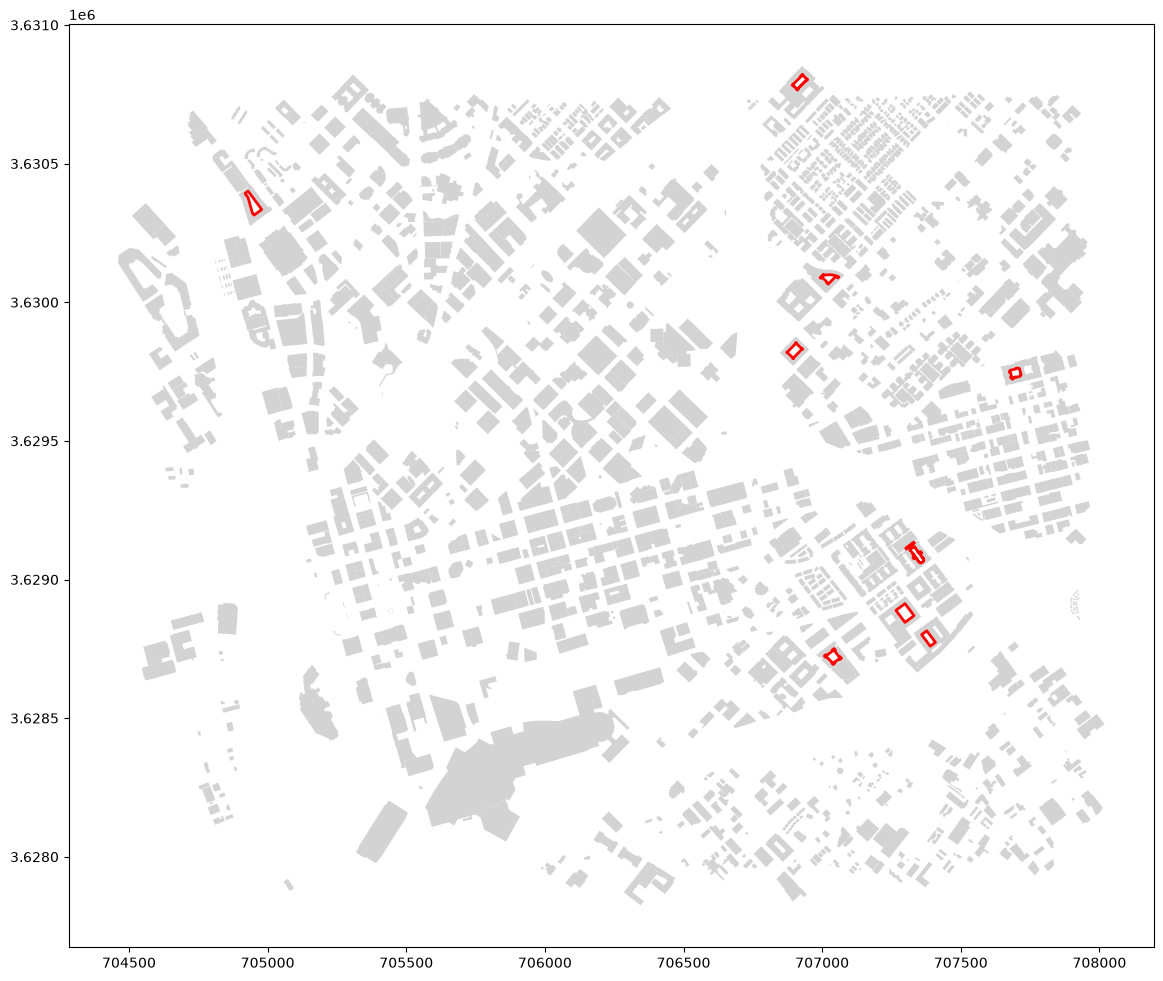

In [30]:
ax = buildings_m.plot(
    figsize=(14, 14),
    color="lightgray"
)

open_candidates.plot(
    ax=ax,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

In [31]:
open_candidates.explore()

In [32]:
candidate_buildings = gpd.sjoin_nearest(
    open_candidates,
    buildings_m[["geometry", "class"]],
    how="left",
    distance_col="distance_to_building"
)

print(
    candidate_buildings[
        ["area_m2", "class", "distance_to_building"]
    ]
    .sort_values("area_m2", ascending=False)
    .to_string(index=False)
)

    area_m2      class  distance_to_building
2215.796873 apartments                   0.0
1905.146460 apartments                   0.0
1493.494426 apartments                   0.0
1493.494426    parking                   0.0
1415.081604 apartments                   0.0
1406.228132 apartments                   0.0
1224.672028 apartments                   0.0
1209.983691 apartments                   0.0
1064.863486 apartments                   0.0
1016.714662 apartments                   0.0


In [33]:
commercial_land = land_m[
    land_m["class"].isin(["commercial", "retail"])
][["class", "geometry"]]

candidate_commercial = gpd.sjoin_nearest(
    open_candidates,
    commercial_land,
    how="left",
    distance_col="distance_to_commercial"
)

print(
    candidate_commercial[
        ["area_m2", "class", "distance_to_commercial"]
    ]
    .sort_values("area_m2", ascending=False)
    .to_string(index=False)
)

    area_m2      class  distance_to_commercial
2215.796873     retail              294.173299
1905.146460 commercial               59.251160
1493.494426     retail              319.376590
1415.081604     retail              258.582242
1406.228132     retail              140.627773
1224.672028     retail              253.802793
1209.983691 commercial              297.422478
1064.863486 commercial               47.213399
1016.714662     retail               40.122134


In [34]:
parking_buildings = buildings_m[
    buildings_m["class"] == "parking"
].copy()

print("Parking-class buildings:", len(parking_buildings))

print(
    parking_buildings[
        ["id", "class", "subtype", "names", "area_m2"]
    ].to_string(index=False)
)

Parking-class buildings: 76
                                  id   class        subtype                                                                                                       names      area_m2
b630d0fc-e3db-41dc-be9a-25731adfc784 parking transportation                                                         {'primary': 'Lot D', 'common': None, 'rules': None} 12383.626233
ce153b84-716d-4e93-897a-f350b2dac169 parking transportation                                                                                                        None 19197.873400
339b6ac6-c358-47e9-a74e-7b55b8db2a2e parking transportation                                                                                                        None  5505.423895
502fcf96-6c1e-46c1-bb8c-45e16f5518f1 parking transportation                                                                                                        None    57.882006
9a8e9c0e-b966-4a2b-a205-936a2b3b9fee parking transportation        

In [35]:
parking_buildings = buildings_m[
    buildings_m["class"] == "parking"
].copy()

print("Parking-class buildings:", len(parking_buildings))

print(
    parking_buildings[
        ["id", "class", "subtype", "names", "area_m2"]
    ].to_string(index=False)
)

Parking-class buildings: 76
                                  id   class        subtype                                                                                                       names      area_m2
b630d0fc-e3db-41dc-be9a-25731adfc784 parking transportation                                                         {'primary': 'Lot D', 'common': None, 'rules': None} 12383.626233
ce153b84-716d-4e93-897a-f350b2dac169 parking transportation                                                                                                        None 19197.873400
339b6ac6-c358-47e9-a74e-7b55b8db2a2e parking transportation                                                                                                        None  5505.423895
502fcf96-6c1e-46c1-bb8c-45e16f5518f1 parking transportation                                                                                                        None    57.882006
9a8e9c0e-b966-4a2b-a205-936a2b3b9fee parking transportation        

<Axes: >

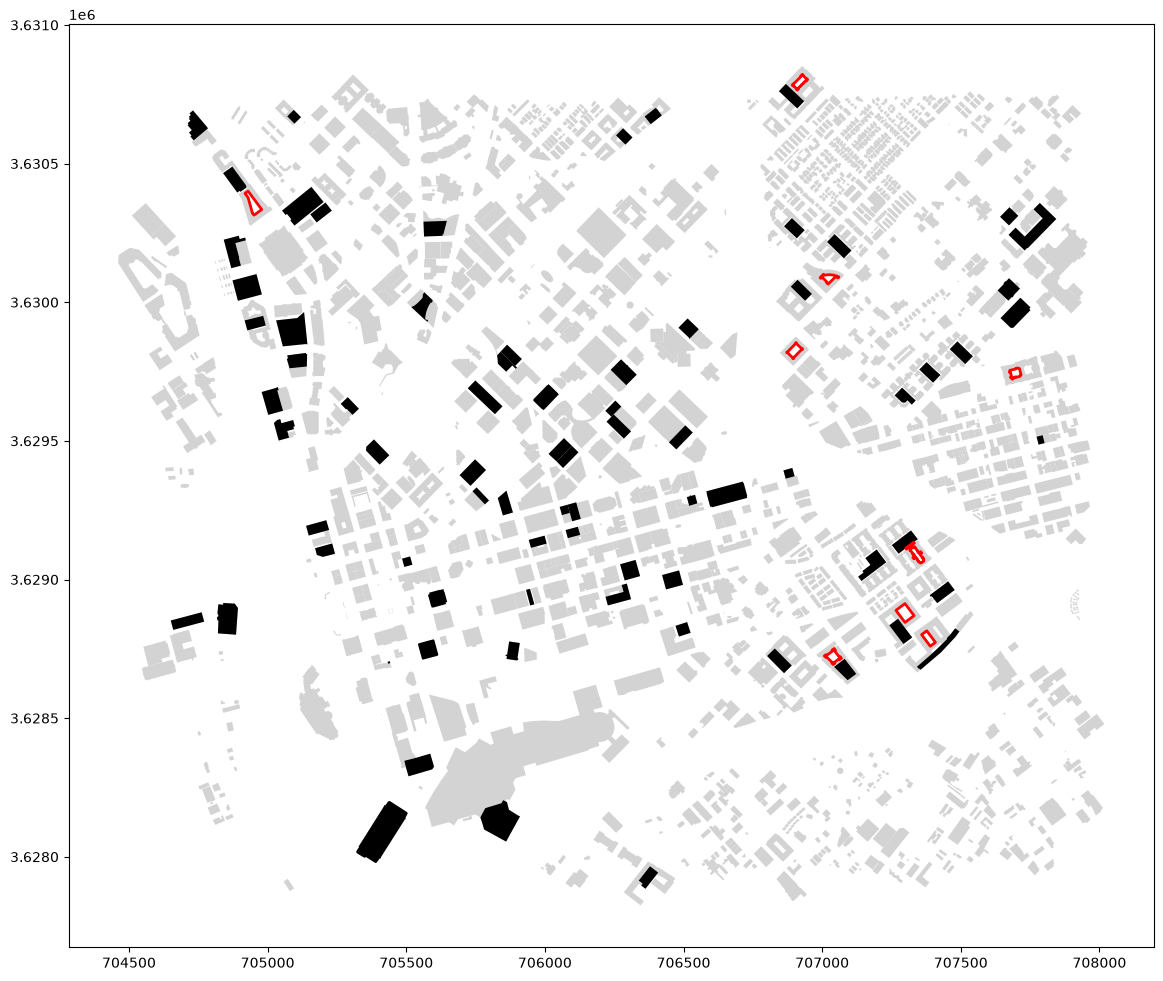

In [36]:
ax = buildings_m.plot(
    figsize=(14, 14),
    color="lightgray"
)

parking_buildings.plot(
    ax=ax,
    color="black"
)

open_candidates.plot(
    ax=ax,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

In [37]:
parking_buildings = buildings_m[
    buildings_m["class"] == "parking"
].copy()

parking_buildings["area_m2"] = parking_buildings.geometry.area

print(
    parking_buildings["area_m2"]
    .describe()
)

count       76.000000
mean      3640.951714
std       2827.559294
min         57.882006
25%       2280.981475
50%       3189.536549
75%       4047.563996
max      19197.873400
Name: area_m2, dtype: float64


In [38]:
print(
    parking_buildings[
        ["area_m2", "subtype", "names"]
    ]
    .sort_values("area_m2", ascending=False)
    .head(30)
    .to_string(index=False)
)

     area_m2        subtype                                                                        names
19197.873400 transportation                                                                         None
12383.626233 transportation                          {'primary': 'Lot D', 'common': None, 'rules': None}
 9488.665070 transportation                {'primary': 'South Victory 1', 'common': None, 'rules': None}
 9355.230957 transportation                   {'primary': 'Lexus Garage', 'common': None, 'rules': None}
 9055.907535 transportation                                                                         None
 8403.289363 transportation              {'primary': 'Elm Street Garage', 'common': None, 'rules': None}
 7487.176005     commercial {'primary': 'Dallas County Parking Garage D', 'common': None, 'rules': None}
 6780.137906 transportation                                                                         None
 5799.897815 transportation              {'primary': 'P

In [39]:
!overturemaps download --help

'overturemaps' is not recognized as an internal or external command,
operable program or batch file.


In [40]:
import overturemaps

print("Overture Maps is installed!")
print(overturemaps.__file__)

ModuleNotFoundError: No module named 'overturemaps'

In [41]:
import sys
!{sys.executable} -m pip install overturemaps

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 9.0 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]
   -------- ------------------------------- 1/5 [pyfiglet]


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [42]:
import overturemaps
print("Overture Maps installed successfully!")

Overture Maps installed successfully!


In [43]:
from overturemaps import geodataframe

# Your existing Dallas study-area bounds
bbox = (
    -96.8166593,  # west
    32.7689828,   # south
    -96.7790675,  # east
    32.7961922    # north
)

infrastructure = geodataframe(
    "infrastructure",
    bbox=bbox
)

print(infrastructure.shape)
print(infrastructure.columns.tolist())

(8685, 13)
['id', 'geometry', 'sources', 'names', 'level', 'wikidata', 'source_tags', 'subtype', 'class', 'height', 'surface', 'version', 'bbox']


In [44]:
print("SUBTYPE VALUES:")
print(infrastructure["subtype"].value_counts(dropna=False))

print("\nCLASS VALUES:")
print(infrastructure["class"].value_counts(dropna=False))

SUBTYPE VALUES:
subtype
transportation      3487
barrier             3052
transit             1416
bridge               381
pedestrian           195
water                 43
waste_management      41
power                 40
emergency             16
airport                7
communication          3
manhole                2
tower                  2
Name: count, dtype: int64

CLASS VALUES:
class
crossing               2724
kerb                   2633
traffic_signals         419
parking                 381
bridge                  379
bicycle_parking         286
gate                    254
bus_stop                253
parking_entrance        250
stop                    176
parking_space           138
bench                   103
street_lamp             101
motorway_junction        62
artwork                  61
platform                 48
stop_position            45
waste_basket             37
fence                    37
bollard                  32
wall                     27
drinking_water  

In [45]:
parking_candidates = infrastructure[
    infrastructure["subtype"].astype(str).str.contains(
        "parking", case=False, na=False
    )
]

print("Parking candidates:", len(parking_candidates))
print(parking_candidates[["id", "subtype", "class", "geometry"]].head(20))

Parking candidates: 0
Empty GeoDataFrame
Columns: [id, subtype, class, geometry]
Index: []


In [50]:
print(parking.geometry.geom_type.value_counts())

Polygon    379
Point        2
Name: count, dtype: int64


In [51]:
parking_polygons = parking[
    parking.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

print("Parking polygons:", len(parking_polygons))
print(parking_polygons.geometry.geom_type.value_counts())

Parking polygons: 379
Polygon    379
Name: count, dtype: int64


In [52]:
print(parking_polygons.crs)

None


In [53]:
parking_polygons = parking_polygons.set_crs("EPSG:4326")

print(parking_polygons.crs)

EPSG:4326


In [54]:
parking_projected = parking_polygons.to_crs("EPSG:32614")

print(parking_projected.crs)

EPSG:32614


In [55]:
print(parking_projected.geometry.head())

22     POLYGON ((704841.746 3630225.569, 704856.014 3...
81     POLYGON ((705317.097 3630132.952, 705323.453 3...
86     POLYGON ((705522.683 3630139.945, 705521.696 3...
104    POLYGON ((705398.007 3630207.283, 705348.137 3...
158    POLYGON ((705219.374 3630192.563, 705231.288 3...
Name: geometry, dtype: geometry


In [56]:
print(parking_projected.crs)

EPSG:32614


In [57]:
parking_buffer = parking_projected.copy()

parking_buffer["geometry"] = parking_buffer.geometry.buffer(500)

print("Number of buffered parking features:", len(parking_buffer))

Number of buffered parking features: 379


In [58]:
parking_buffer_dissolved = parking_buffer.dissolve()

print("Dissolved buffer features:", len(parking_buffer_dissolved))

Dissolved buffer features: 1


In [59]:
parking_buffer_dissolved.explore()

In [60]:
jupyter trust d.ipynb


SyntaxError: invalid syntax (3615108109.py, line 1)

In [49]:
parking_candidates.explore()

C:\Users\gunja\AppData\Local\Temp\ipykernel_16284\2435881926.py:1: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  parking_candidates.explore()


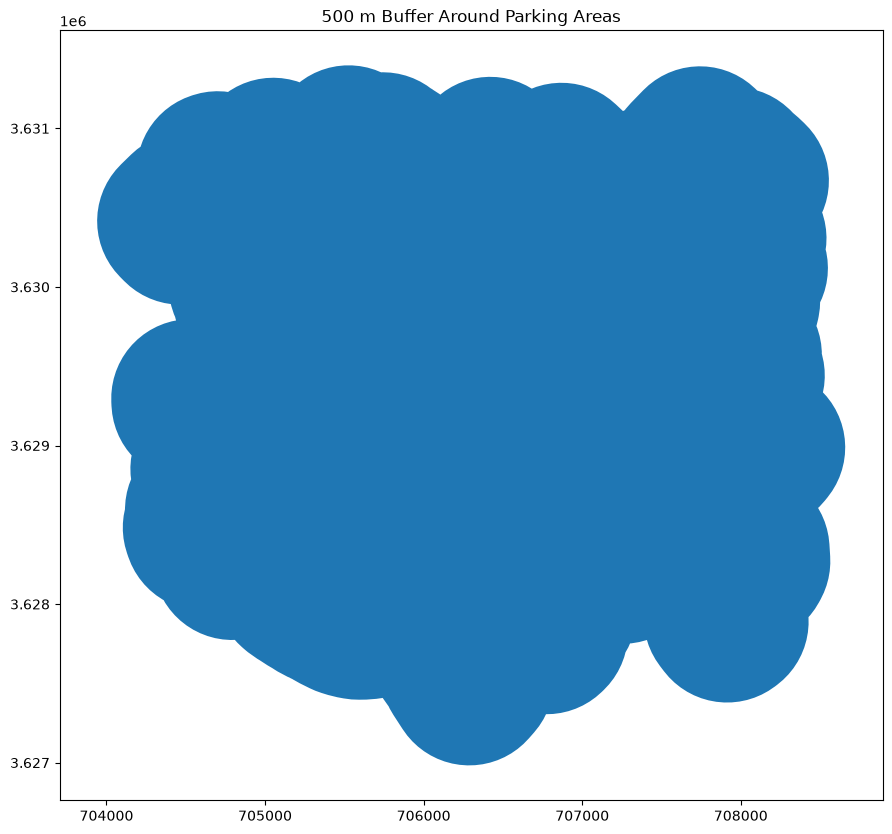

In [62]:
import matplotlib.pyplot as plt

parking_buffer_dissolved.plot(figsize=(12, 10))
plt.title("500 m Buffer Around Parking Areas")
plt.show()

In [61]:
my_map.save("map.html")
# You can now open map.html directly in your web browser


NameError: name 'my_map' is not defined

C:\Users\gunja\AppData\Local\Temp\ipykernel_16284\355170157.py:3: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  parking_candidates.plot(figsize=(12, 10))


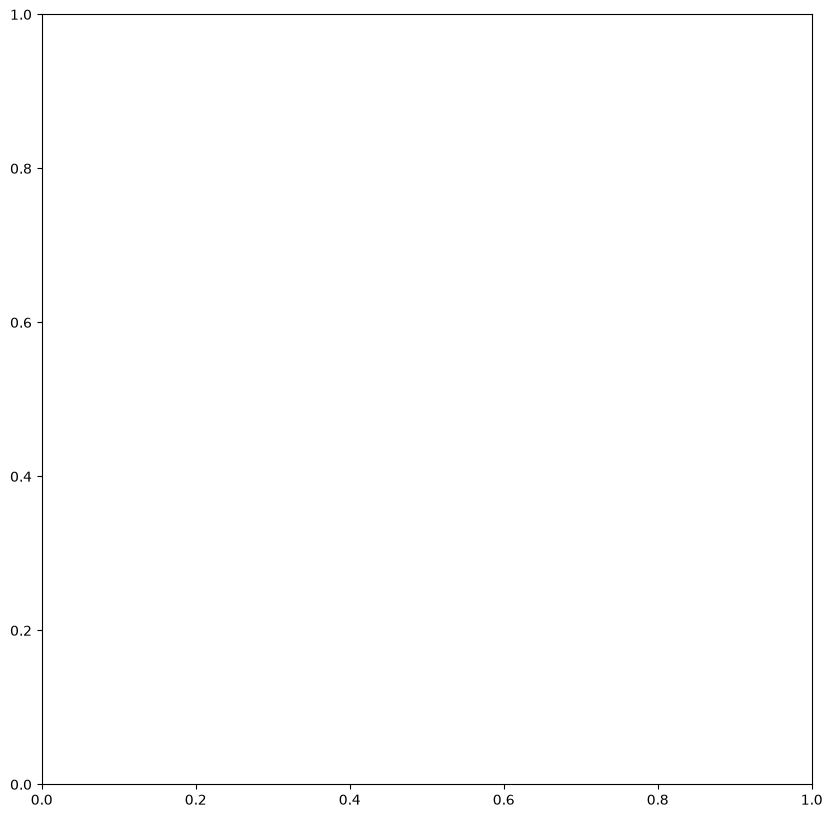

In [47]:
import matplotlib.pyplot as plt

parking_candidates.plot(figsize=(12, 10))
plt.show()

In [63]:
print("Dissolved buffer features:", len(parking_buffer_dissolved))

Dissolved buffer features: 1


In [64]:
from overturemaps import geodataframe

roads = geodataframe(
    "transportation",
    bbox=bbox
)

print(roads.shape)
print(roads.columns.tolist())

KeyError: 'transportation'

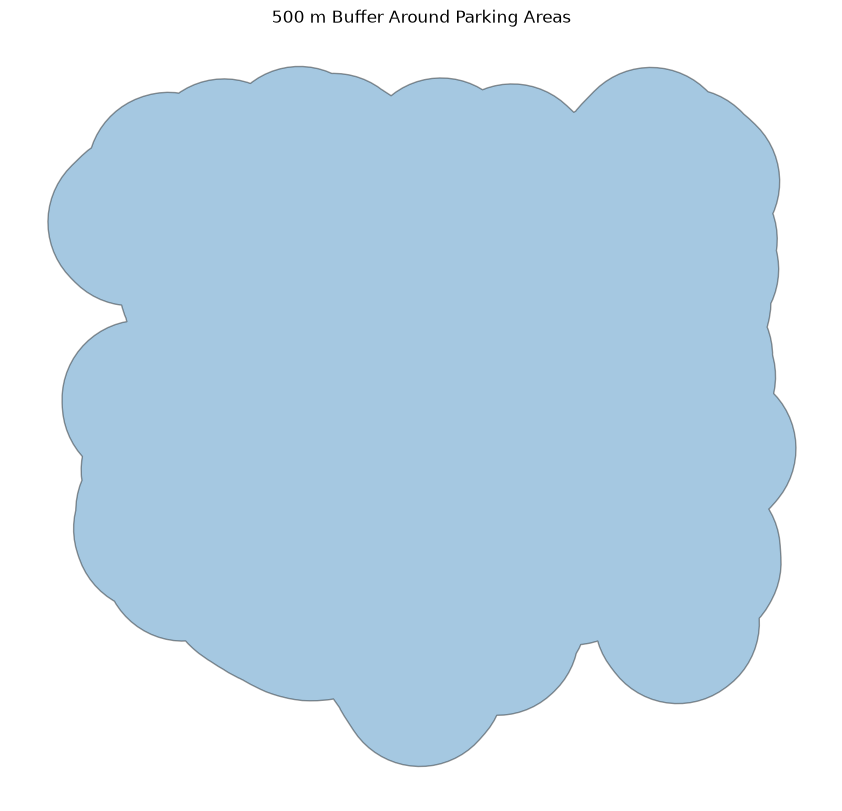

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

parking_buffer_dissolved.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black"
)

ax.set_title("500 m Buffer Around Parking Areas")
ax.set_axis_off()

plt.show()

In [66]:
from overturemaps import geodataframe

roads = geodataframe(
    "transportation",
    bbox=bbox
)

print(roads.shape)
print(roads.columns.tolist())

KeyError: 'transportation'

In [67]:
import overturemaps

print(overturemaps.__version__)

AttributeError: module 'overturemaps' has no attribute '__version__'

In [68]:
print("Parking polygons:", len(parking_polygons))
print("Buffered features:", len(parking_buffer))
print("Dissolved features:", len(parking_buffer_dissolved))
print("CRS:", parking_buffer_dissolved.crs)

Parking polygons: 379
Buffered features: 379
Dissolved features: 1
CRS: EPSG:32614


In [69]:
buffer_area_m2 = parking_buffer_dissolved.geometry.area.iloc[0]

print(f"Buffer area: {buffer_area_m2:,.2f} m²")
print(f"Buffer area: {buffer_area_m2 / 1_000_000:.2f} km²")

Buffer area: 16,755,473.76 m²
Buffer area: 16.76 km²


In [70]:
parking_area_m2 = parking_polygons.to_crs("EPSG:32614").geometry.area.sum()

print(f"Parking area: {parking_area_m2:,.2f} m²")
print(f"Parking area: {parking_area_m2 / 1_000_000:.4f} km²")

Parking area: 1,227,260.56 m²
Parking area: 1.2273 km²


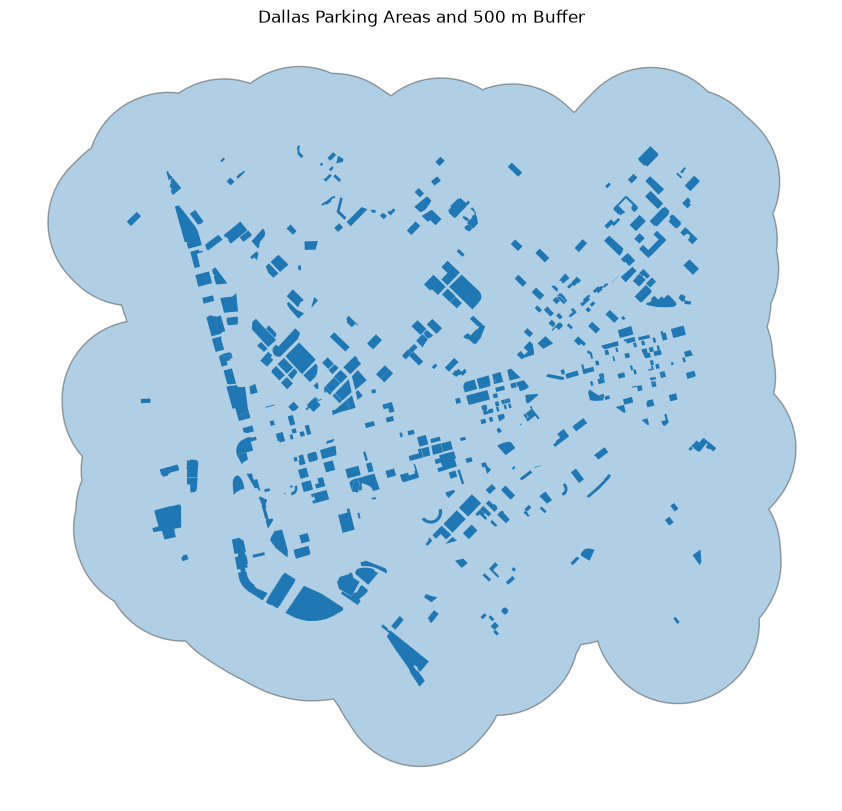

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

parking_buffer_dissolved.plot(
    ax=ax,
    alpha=0.35,
    edgecolor="black"
)

parking_projected.plot(
    ax=ax,
    markersize=2
)

ax.set_title("Dallas Parking Areas and 500 m Buffer")
ax.set_axis_off()

plt.show()

In [72]:
parking_area_m2 = parking_projected.geometry.area.sum()

print(f"Parking area: {parking_area_m2:,.2f} m²")
print(f"Parking area: {parking_area_m2 / 1_000_000:.4f} km²")

Parking area: 1,227,260.56 m²
Parking area: 1.2273 km²


In [73]:
percentage = (parking_area_m2 / buffer_area_m2) * 100

print(f"Parking occupies {percentage:.2f}% of the 500 m buffer area.")

Parking occupies 7.32% of the 500 m buffer area.


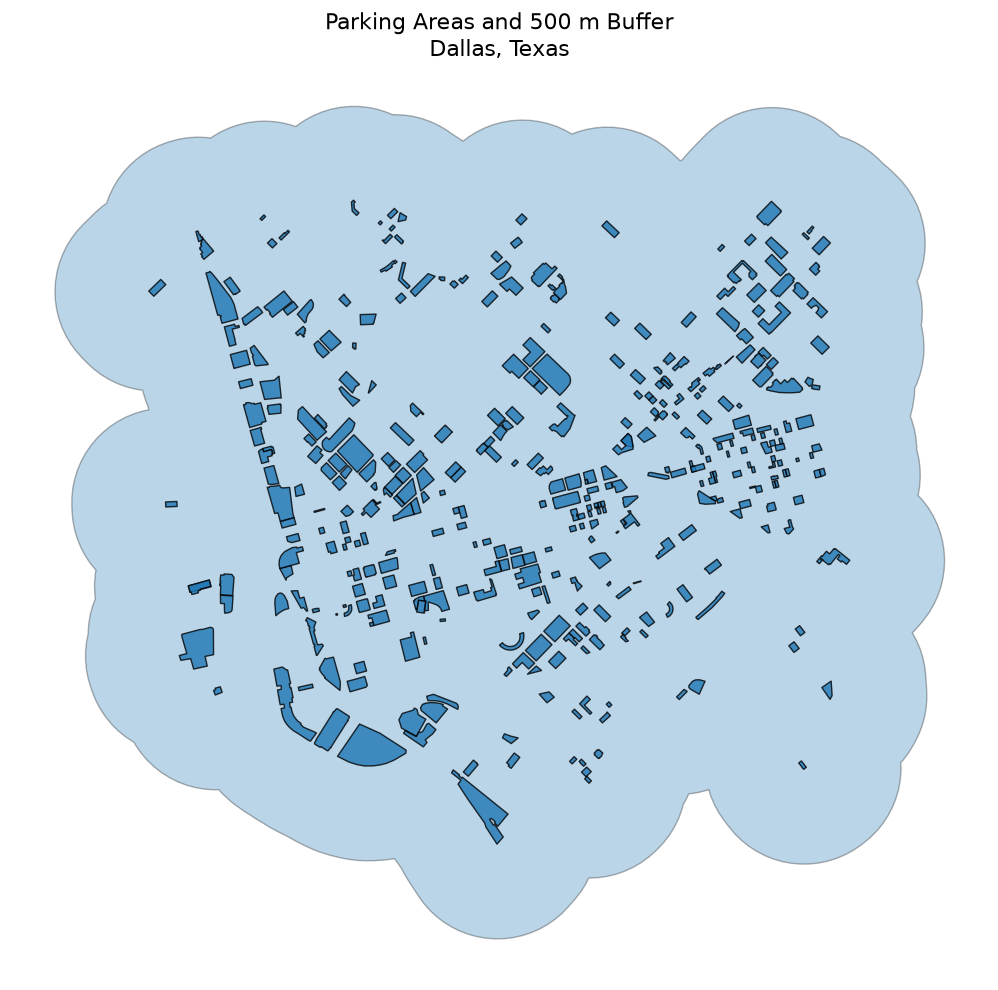

In [74]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# 500 m buffer
parking_buffer_dissolved.plot(
    ax=ax,
    alpha=0.3,
    edgecolor="black"
)

# Parking polygons
parking_projected.plot(
    ax=ax,
    alpha=0.8,
    edgecolor="black"
)

ax.set_title(
    "Parking Areas and 500 m Buffer\nDallas, Texas",
    fontsize=16
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [75]:
import geopandas as gpd
from shapely.geometry import box

study_area = gpd.GeoDataFrame(
    geometry=[box(*bbox)],
    crs="EPSG:4326"
)

study_area_projected = study_area.to_crs("EPSG:32614")

print(study_area_projected.crs)

EPSG:32614


In [76]:
parking_buffer_clipped = gpd.overlay(
    parking_buffer_dissolved,
    study_area_projected,
    how="intersection"
)

print("Clipped buffer features:", len(parking_buffer_clipped))

clipped_area = parking_buffer_clipped.geometry.area.sum()

print(f"Clipped buffer area: {clipped_area:,.2f} m²")
print(f"Clipped buffer area: {clipped_area / 1_000_000:.2f} km²")

Clipped buffer features: 1
Clipped buffer area: 10,624,164.62 m²
Clipped buffer area: 10.62 km²


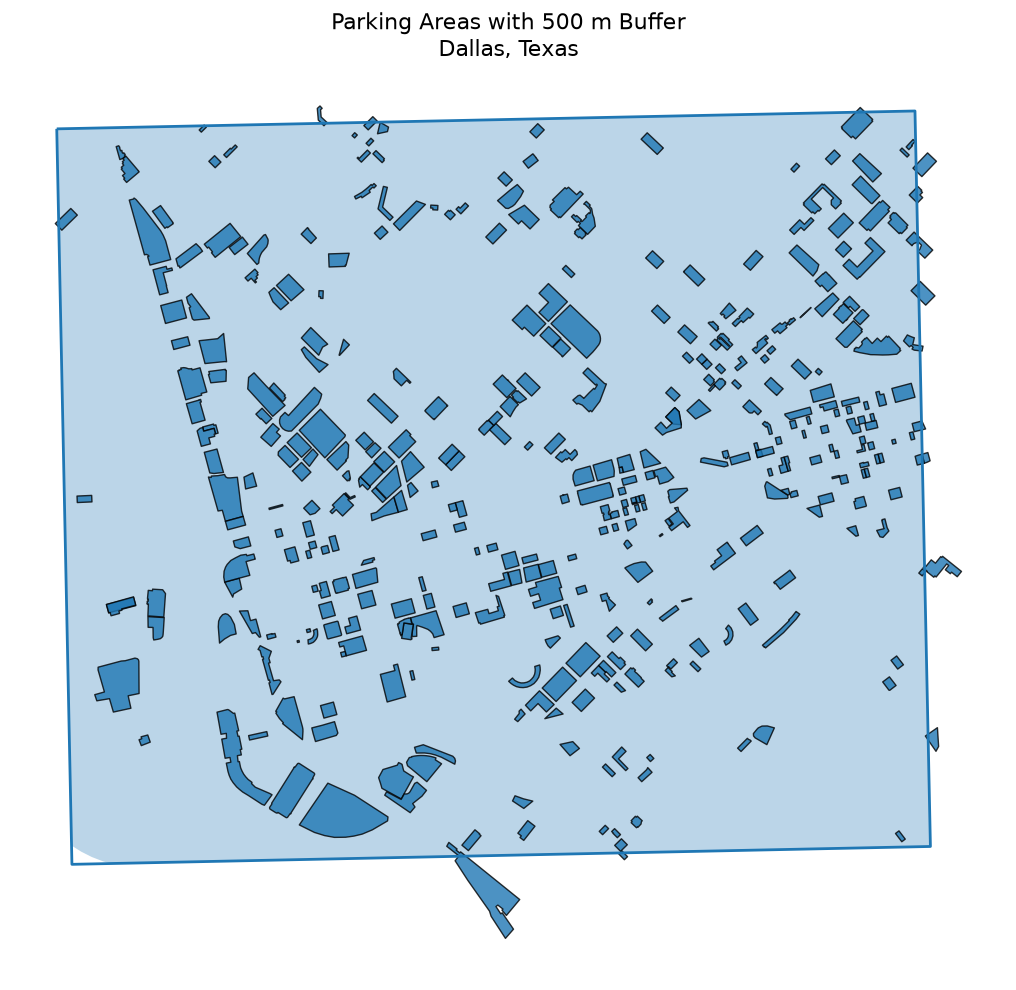

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# Study-area boundary
study_area_projected.boundary.plot(
    ax=ax,
    linewidth=2
)

# 500 m parking buffer
parking_buffer_clipped.plot(
    ax=ax,
    alpha=0.3
)

# Parking areas
parking_projected.plot(
    ax=ax,
    alpha=0.8,
    edgecolor="black"
)

ax.set_title(
    "Parking Areas with 500 m Buffer\nDallas, Texas",
    fontsize=16
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [78]:
import geopandas as gpd

output_file = "dallas_parking_buffer.gpkg"

# 1. Parking polygons
parking_projected.to_file(
    output_file,
    layer="parking_500m_source",
    driver="GPKG"
)

# 2. 500 m buffer
parking_buffer_clipped.to_file(
    output_file,
    layer="parking_buffer_500m",
    driver="GPKG"
)

# 3. Study area
study_area_projected.to_file(
    output_file,
    layer="study_area",
    driver="GPKG"
)

print("Export complete!")
print(output_file)

c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


Export complete!
dallas_parking_buffer.gpkg


In [79]:
import os

print(os.getcwd())
print(os.path.abspath("dallas_parking_buffer.gpkg"))

c:\Users\gunja\Desktop\QGIS Project
c:\Users\gunja\Desktop\QGIS Project\dallas_parking_buffer.gpkg


In [80]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import folium

print("GeoPandas:", gpd.__version__)
print("Pandas:", pd.__version__)
print("Folium:", folium.__version__)
print("All basic packages loaded successfully.")

GeoPandas: 1.1.4
Pandas: 3.0.5
Folium: 0.20.0
All basic packages loaded successfully.


In [81]:
import requests
from pathlib import Path

gtfs_url = "https://www.dart.org/docs/default-source/default-document-library/gtfs.zip"

response = requests.get(gtfs_url)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 404
File size: 17511 bytes


In [82]:
import requests

gtfs_url = "http://www.dart.org/transitdata/latest/google_transit.zip"

response = requests.get(gtfs_url)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 200
File size: 8538309 bytes


In [83]:
from pathlib import Path

gtfs_file = Path("dart_gtfs.zip")

gtfs_file.write_bytes(response.content)

print("Saved:", gtfs_file.resolve())

Saved: C:\Users\gunja\Desktop\QGIS Project\dart_gtfs.zip


In [84]:
import zipfile
import pandas as pd

with zipfile.ZipFile(gtfs_file, "r") as z:
    print(z.namelist())

['agency.txt', 'blocks.txt', 'calendar.txt', 'calendar_dates.txt', 'facilities.txt', 'fare_attributes.txt', 'fare_rules.txt', 'feed_info.txt', 'info.txt', 'nodes.txt', 'route_direction.txt', 'routes.txt', 'shapes.txt', 'stop_times.txt', 'stops.txt', 'trips.txt']


In [85]:
with zipfile.ZipFile(gtfs_file, "r") as z:
    stops = pd.read_csv(z.open("stops.txt"))

print("Number of stops:", len(stops))
print(stops.columns.tolist())
print(stops.head())

Number of stops: 6978
['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'wheelchair_boarding']
   stop_id  stop_code                          stop_name  \
0    12901      12901         FOREST @ SHEPHERD - E - NS   
1    12908      12908     WALNUT HILL @ RAMBLER - W - MB   
2    12909      12909  WALNUT HILL @ GREENVILLE - E - MB   
3    12916      12916         MATILDA @ PENROSE - S - NS   
4    12917      12917        MATILDA @ MCCOMMAS - S - NS   

                                           stop_desc   stop_lat   stop_lon  \
0  FOREST @ SHEPHERD -Eastbound -Near Side (befor...  32.909084 -96.750428   
1  WALNUT HILL @ RAMBLER -Westbound -Mid Block (n...  32.883429 -96.760942   
2  WALNUT HILL @ GREENVILLE -Eastbound -Mid Block...  32.883151 -96.760168   
3  MATILDA @ PENROSE -Southbound -Near Side (befo...  32.832439 -96.767991   
4  MATILDA @ MCCOMMAS -Southbound -Near Side (bef...  32.830131 -96.767975   

   zone_id  stop_url  wheel

In [86]:
transit_stops = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(
        stops.stop_lon,
        stops.stop_lat
    ),
    crs="EPSG:4326"
)

transit_stops = transit_stops.to_crs("EPSG:32614")

print("Transit stops:", len(transit_stops))
print("CRS:", transit_stops.crs)

Transit stops: 6978
CRS: EPSG:32614


In [87]:
transit_stops_study = gpd.sjoin(
    transit_stops,
    study_area_projected,
    predicate="within",
    how="inner"
)

print("Transit stops inside study area:", len(transit_stops_study))

Transit stops inside study area: 222


In [88]:
print("Number of stops:", len(stops))
print("Transit stops inside study area:", len(transit_stops_study))

Number of stops: 6978
Transit stops inside study area: 222


In [89]:
parking_transit = gpd.sjoin_nearest(
    parking_projected,
    transit_stops_study[["stop_id", "stop_name", "geometry"]],
    how="left",
    distance_col="distance_to_transit_m"
)

print("Parking lots:", len(parking_transit))
print(parking_transit[
    ["id", "stop_name", "distance_to_transit_m"]
].head(10))

Parking lots: 379
                                       id                       stop_name  \
22   c597ce9a-213c-32cf-8c84-13846eb3a908                 VICTORY STATION   
81   4d85095c-b01a-3838-8244-d1a33b29edd9          FIELD @ OLIVE - N - NS   
86   5b631f30-4bd3-3037-9664-d321858252e0     MCKINNEY @ HARWOOD - S - NS   
104  34330904-10fa-3fd8-b292-8ada05820a29          FIELD @ OLIVE - N - NS   
158  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee          FIELD @ OLIVE - N - NS   
181  749e2d70-b829-379b-99e5-c51f32dff662          FIELD @ OLIVE - N - NS   
183  5837fa94-cd7b-31d9-92f2-2d59691c3471          FIELD @ OLIVE - N - NS   
203  de1dfe96-9fe5-3bc3-8fd7-28eecc210a05     MCKINNEY @ HARWOOD - S - NS   
238  c46e103d-06ec-3ce2-8450-b00e03a78cc8  PEARL @ CEDAR SPRINGS - E - NS   
304  23e45b22-3141-307f-8774-c75673aae886          FIELD @ OLIVE - N - NS   

     distance_to_transit_m  
22               45.359789  
81                5.534486  
86              179.462941  
104              4

In [90]:
print(
    parking_transit["distance_to_transit_m"].describe()
)

count    379.000000
mean      89.180233
std       98.876955
min        0.000000
25%       24.784797
50%       66.944438
75%      118.815091
max      822.598036
Name: distance_to_transit_m, dtype: float64


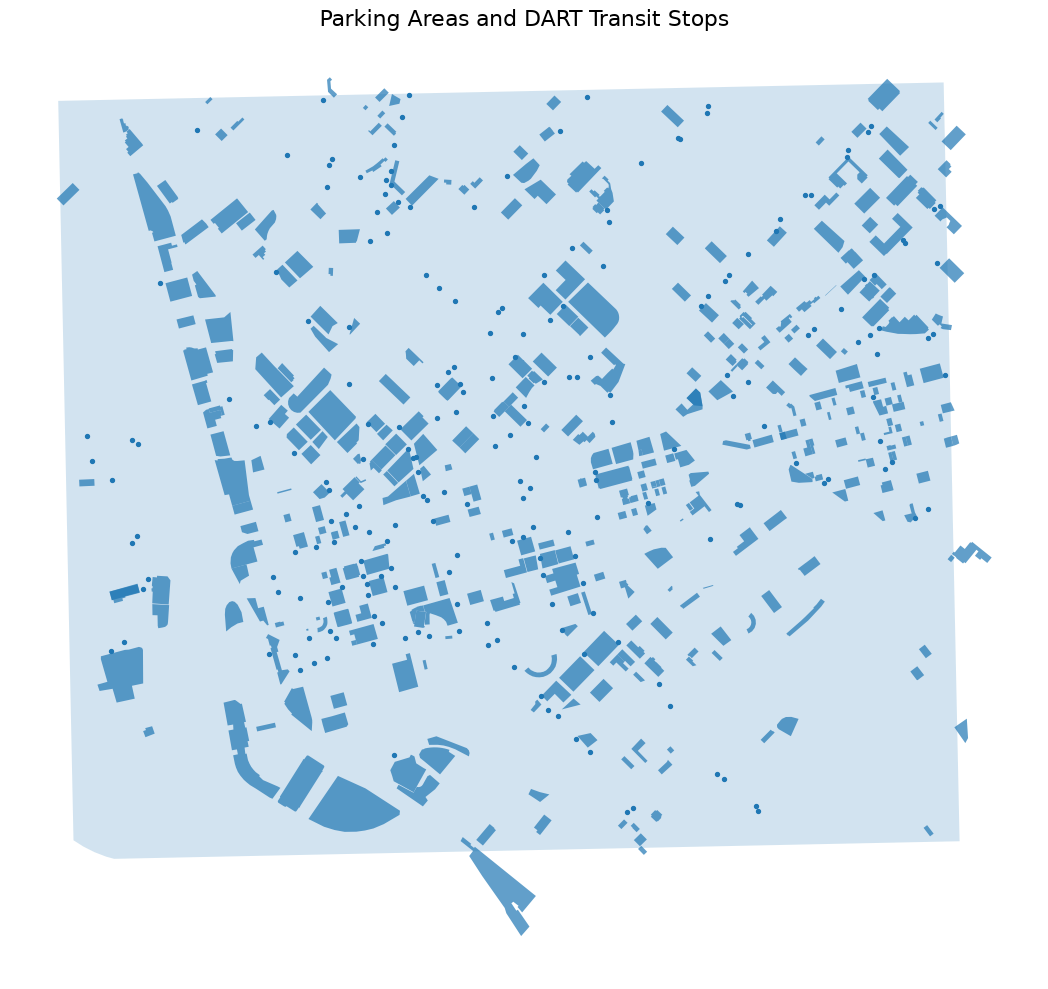

In [91]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

parking_buffer_clipped.plot(
    ax=ax,
    alpha=0.2
)

transit_stops_study.plot(
    ax=ax,
    markersize=8
)

parking_projected.plot(
    ax=ax,
    alpha=0.7
)

ax.set_title(
    "Parking Areas and DART Transit Stops",
    fontsize=16
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [92]:
min_dist = parking_transit["distance_to_transit_m"].min()
max_dist = parking_transit["distance_to_transit_m"].max()

parking_transit["transit_score"] = (
    100
    * (max_dist - parking_transit["distance_to_transit_m"])
    / (max_dist - min_dist)
)

print(
    parking_transit[
        ["id", "stop_name", "distance_to_transit_m", "transit_score"]
    ].head(10)
)

                                       id                       stop_name  \
22   c597ce9a-213c-32cf-8c84-13846eb3a908                 VICTORY STATION   
81   4d85095c-b01a-3838-8244-d1a33b29edd9          FIELD @ OLIVE - N - NS   
86   5b631f30-4bd3-3037-9664-d321858252e0     MCKINNEY @ HARWOOD - S - NS   
104  34330904-10fa-3fd8-b292-8ada05820a29          FIELD @ OLIVE - N - NS   
158  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee          FIELD @ OLIVE - N - NS   
181  749e2d70-b829-379b-99e5-c51f32dff662          FIELD @ OLIVE - N - NS   
183  5837fa94-cd7b-31d9-92f2-2d59691c3471          FIELD @ OLIVE - N - NS   
203  de1dfe96-9fe5-3bc3-8fd7-28eecc210a05     MCKINNEY @ HARWOOD - S - NS   
238  c46e103d-06ec-3ce2-8450-b00e03a78cc8  PEARL @ CEDAR SPRINGS - E - NS   
304  23e45b22-3141-307f-8774-c75673aae886          FIELD @ OLIVE - N - NS   

     distance_to_transit_m  transit_score  
22               45.359789      94.485789  
81                5.534486      99.327194  
86              179.

In [93]:
print(parking_transit["transit_score"].describe())

count    379.000000
mean      89.158711
std       12.020082
min        0.000000
25%       85.556118
50%       91.861829
75%       96.987010
max      100.000000
Name: transit_score, dtype: float64


In [94]:
parking_transit["parking_area_m2"] = parking_transit.geometry.area

print(
    parking_transit["parking_area_m2"].describe()
)

count      379.000000
mean      3238.154510
std       4450.164850
min         57.882006
25%        873.975790
50%       1997.336514
75%       3870.257922
max      47783.779278
Name: parking_area_m2, dtype: float64


In [95]:
min_area = parking_transit["parking_area_m2"].min()
max_area = parking_transit["parking_area_m2"].max()

parking_transit["size_score"] = (
    100
    * (parking_transit["parking_area_m2"] - min_area)
    / (max_area - min_area)
)

print(
    parking_transit[
        ["id", "parking_area_m2", "size_score"]
    ].head(10)
)

                                       id  parking_area_m2  size_score
22   c597ce9a-213c-32cf-8c84-13846eb3a908      4555.478212    9.423806
81   4d85095c-b01a-3838-8244-d1a33b29edd9      3436.123847    7.078425
86   5b631f30-4bd3-3037-9664-d321858252e0       497.865270    0.921896
104  34330904-10fa-3fd8-b292-8ada05820a29      6066.346218   12.589526
158  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee      1441.664462    2.899437
181  749e2d70-b829-379b-99e5-c51f32dff662      2573.528449    5.271030
183  5837fa94-cd7b-31d9-92f2-2d59691c3471      4611.271393    9.540710
203  de1dfe96-9fe5-3bc3-8fd7-28eecc210a05      4085.435461    8.438927
238  c46e103d-06ec-3ce2-8450-b00e03a78cc8      1906.716897    3.873861
304  23e45b22-3141-307f-8774-c75673aae886      9355.230957   19.480721


In [96]:
print(parking_transit["size_score"].describe())

count    379.000000
mean       6.663620
std        9.324424
min        0.000000
25%        1.709960
50%        4.063736
75%        7.988065
max      100.000000
Name: size_score, dtype: float64


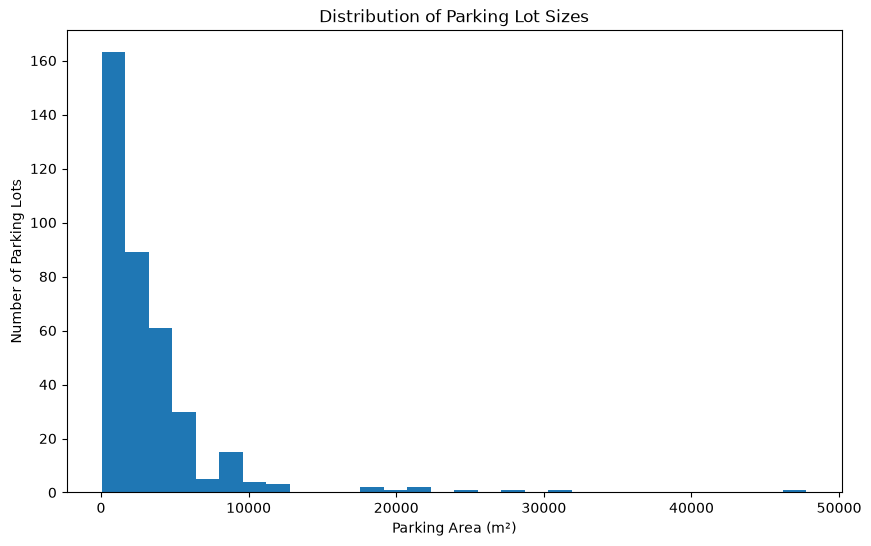

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    parking_transit["parking_area_m2"],
    bins=30
)

plt.xlabel("Parking Area (m²)")
plt.ylabel("Number of Parking Lots")
plt.title("Distribution of Parking Lot Sizes")

plt.show()

In [98]:
print("Parking area statistics:")
print(parking_transit["parking_area_m2"].describe())

Parking area statistics:
count      379.000000
mean      3238.154510
std       4450.164850
min         57.882006
25%        873.975790
50%       1997.336514
75%       3870.257922
max      47783.779278
Name: parking_area_m2, dtype: float64


In [99]:
print("Parking area statistics:")
print(parking_transit["parking_area_m2"].describe())

Parking area statistics:
count      379.000000
mean      3238.154510
std       4450.164850
min         57.882006
25%        873.975790
50%       1997.336514
75%       3870.257922
max      47783.779278
Name: parking_area_m2, dtype: float64


In [100]:
area = parking_transit["parking_area_m2"]

print("20th percentile:", area.quantile(0.20))
print("40th percentile:", area.quantile(0.40))
print("60th percentile:", area.quantile(0.60))
print("80th percentile:", area.quantile(0.80))

20th percentile: 731.3159540279028
40th percentile: 1548.6623185055018
60th percentile: 2642.7616476545045
80th percentile: 4536.0263290877865


In [101]:
bins = [
    0,
    area.quantile(0.20),
    area.quantile(0.40),
    area.quantile(0.60),
    area.quantile(0.80),
    area.max()
]

labels = [
    "Very Small (0–20%)",
    "Small (20–40%)",
    "Medium (40–60%)",
    "Large (60–80%)",
    "Very Large (80–100%)"
]

parking_transit["size_category"] = pd.cut(
    area,
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(
    parking_transit["size_category"]
    .value_counts()
    .sort_index()
)

size_category
Very Small (0–20%)      76
Small (20–40%)          76
Medium (40–60%)         75
Large (60–80%)          76
Very Large (80–100%)    76
Name: count, dtype: int64


In [102]:
print(
    parking_transit[
        ["id", "parking_area_m2", "distance_to_transit_m"]
    ]
    .sort_values("parking_area_m2", ascending=False)
    .head(15)
)

                                        id  parking_area_m2  \
8143  e212b509-3d09-3537-9a0f-8a763c3a9745     47783.779278   
8000  df6d03ba-3256-35a4-b0b1-1890345df5c3     31016.121613   
8336  7ab21fc7-4a2c-324c-9074-31194f68579f     27265.215313   
8283  5f20a5c7-214f-3211-b685-ecfc950bc229     25475.787199   
3571  78df87cb-8656-3660-9185-ba312d85f47e     21885.365738   
316   705da90f-eca4-363f-b412-0361ed71dc06     20768.624404   
8132  d0450fbe-e873-3fa1-86fb-c1e74c8a9872     19197.873400   
4313  44775b85-51ad-3045-9f65-b196e55f12ec     18922.105591   
4612  5caaed02-143a-3a5f-8e2f-14883fb5dd83     17780.002120   
7674  5805fcfe-cab0-3a26-b5ee-4b4ef5455529     12383.626233   
4285  ea1197cb-04a2-3eb1-9392-b2aef28a007e     12060.481753   
4236  fb87d37b-1c92-3c16-8271-39168ee24132     11460.505681   
5571  00e84868-b896-3906-98aa-b798c1b0debf     11011.717247   
8303  5216e81a-a1df-3671-9326-eba5d25d2fb9     10831.564851   
4052  4dda484f-a0fa-3d26-8bfb-b0361596a503     10734.28

In [103]:
parking_transit["size_score"] = pd.cut(
    parking_transit["parking_area_m2"],
    bins=[
        -float("inf"),
        area.quantile(0.20),
        area.quantile(0.40),
        area.quantile(0.60),
        area.quantile(0.80),
        float("inf")
    ],
    labels=[20, 40, 60, 80, 100],
    include_lowest=True
).astype(int)

print(
    parking_transit[
        ["id", "parking_area_m2", "size_score"]
    ].head(15)
)

                                       id  parking_area_m2  size_score
22   c597ce9a-213c-32cf-8c84-13846eb3a908      4555.478212         100
81   4d85095c-b01a-3838-8244-d1a33b29edd9      3436.123847          80
86   5b631f30-4bd3-3037-9664-d321858252e0       497.865270          20
104  34330904-10fa-3fd8-b292-8ada05820a29      6066.346218         100
158  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee      1441.664462          40
181  749e2d70-b829-379b-99e5-c51f32dff662      2573.528449          60
183  5837fa94-cd7b-31d9-92f2-2d59691c3471      4611.271393         100
203  de1dfe96-9fe5-3bc3-8fd7-28eecc210a05      4085.435461          80
238  c46e103d-06ec-3ce2-8450-b00e03a78cc8      1906.716897          60
304  23e45b22-3141-307f-8774-c75673aae886      9355.230957         100
316  705da90f-eca4-363f-b412-0361ed71dc06     20768.624404         100
318  0ab8d023-629c-31a4-a636-4c8991d7b540      4540.330439         100
334  c9b8bdee-31e9-3b26-ae56-fc9fc84fd05b      3391.158817          80
380  f

In [104]:
print(parking_transit["size_score"].value_counts().sort_index())

size_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64


In [105]:
print("Infrastructure classes:")
print(
    infrastructure["class"]
    .value_counts()
    .head(30)
)

Infrastructure classes:
class
crossing             2724
kerb                 2633
traffic_signals       419
parking               381
bridge                379
bicycle_parking       286
gate                  254
bus_stop              253
parking_entrance      250
stop                  176
parking_space         138
bench                 103
street_lamp           101
motorway_junction      62
artwork                61
platform               48
stop_position          45
waste_basket           37
fence                  37
bollard                32
wall                   27
drinking_water         25
power_tower            21
lift_gate              21
fountain               18
toilets                17
fire_hydrant           16
hedge                  16
railway_station        11
barrier                 9
Name: count, dtype: int64


In [106]:
print("\nInfrastructure subtypes:")
print(
    infrastructure["subtype"]
    .value_counts()
    .head(30)
)


Infrastructure subtypes:
subtype
transportation      3487
barrier             3052
transit             1416
bridge               381
pedestrian           195
water                 43
waste_management      41
power                 40
emergency             16
airport                7
communication          3
manhole                2
tower                  2
Name: count, dtype: int64


In [107]:
print(
    infrastructure[
        infrastructure["class"].astype(str).str.contains(
            "park|green|recreation|garden|open",
            case=False,
            na=False
        )
    ][["id", "class", "subtype"]]
    .head(30)
)

                                       id             class  subtype
6    d181e9fc-2ba5-3da0-a810-3a7aabdc260a  parking_entrance  transit
20   de04e6bc-d085-3387-9fb0-444634dfede7  parking_entrance  transit
21   b3782cf1-a4e4-36f7-b0ee-ab905c5b914e           parking  transit
22   c597ce9a-213c-32cf-8c84-13846eb3a908           parking  transit
42   504c809b-e789-3444-a6fa-2a2a43592493   bicycle_parking  transit
46   1b1d3f7a-9b87-357a-9fbe-6a8bde89f454  parking_entrance  transit
48   dee27664-2f10-39e1-810a-eead30d3422d   bicycle_parking  transit
71   0ec3874a-0b98-3097-9fe1-104f5a1f9403   bicycle_parking  transit
81   4d85095c-b01a-3838-8244-d1a33b29edd9           parking  transit
82   352a8e0f-0936-3ee3-982d-151c8f1fae73   bicycle_parking  transit
86   5b631f30-4bd3-3037-9664-d321858252e0           parking  transit
104  34330904-10fa-3fd8-b292-8ada05820a29           parking  transit
112  d5b514fb-47c5-33c4-8578-2b2695956660  parking_entrance  transit
129  0efd7a9e-52c2-3393-aefe-9442f

In [108]:
land_use = geodataframe(
    "land_use",
    bbox=bbox
)

print("Shape:", land_use.shape)
print("Columns:")
print(land_use.columns.tolist())

Shape: (443, 13)
Columns:
['id', 'geometry', 'sources', 'names', 'level', 'wikidata', 'source_tags', 'subtype', 'class', 'elevation', 'surface', 'version', 'bbox']


In [109]:
print(
    land_use["subtype"].value_counts().head(30)
)

subtype
managed           140
developed          95
residential        64
park               54
pedestrian         21
transportation     18
recreation         17
horticulture       12
construction       10
education           7
religious           2
protected           1
medical             1
cemetery            1
Name: count, dtype: int64


In [110]:
print(
    land_use["class"].value_counts().head(30)
)

class
grass                140
residential           64
commercial            53
park                  47
retail                26
pedestrian            21
railway               18
brownfield            16
construction           9
pitch                  8
playground             8
dog_park               7
flowerbed              6
garden                 6
school                 3
college                2
university             2
religious              2
protected              1
hospital               1
greenfield             1
cemetery               1
recreation_ground      1
Name: count, dtype: int64


In [111]:
green_classes = [
    "grass",
    "park",
    "recreation_ground",
    "garden",
    "flowerbed",
    "dog_park",
    "greenfield",
    "protected",
    "cemetery"
]

green_space = land_use[
    land_use["class"].isin(green_classes)
].copy()

print("Green/open-space features:", len(green_space))
print(green_space["class"].value_counts())

Green/open-space features: 210
class
grass                140
park                  47
dog_park               7
flowerbed              6
garden                 6
protected              1
greenfield             1
cemetery               1
recreation_ground      1
Name: count, dtype: int64


In [112]:
print(green_space.geometry.geom_type.value_counts())

Polygon         208
MultiPolygon      2
Name: count, dtype: int64


In [113]:
if green_space.crs is None:
    green_space = green_space.set_crs("EPSG:4326")

green_space_projected = green_space.to_crs("EPSG:32614")

print(green_space_projected.crs)

EPSG:32614


In [114]:
parking_green = parking_transit.copy()

parking_green["geometry"] = (
    parking_green.geometry.buffer(500)
)

print("Parking buffers created:", len(parking_green))

Parking buffers created: 379


In [115]:
green_intersection = gpd.overlay(
    parking_green[["id", "geometry"]],
    green_space_projected[["class", "geometry"]],
    how="intersection"
)

print("Green-space intersections:", len(green_intersection))

Green-space intersections: 7980


In [116]:
green_intersection["green_area_m2"] = (
    green_intersection.geometry.area
)

green_area_by_parking = (
    green_intersection
    .groupby("id")["green_area_m2"]
    .sum()
    .reset_index()
)

print(green_area_by_parking.head())

                                     id  green_area_m2
0  00e84868-b896-3906-98aa-b798c1b0debf  149525.559356
1  0153aaa5-b482-32c1-b815-15afde53e661   79718.605432
2  016ab403-2ee1-3bd4-b4bc-09be73f57dde   91464.348640
3  027a174d-7b58-3085-a010-247381e647dc   33726.832921
4  028c0686-c8d3-3af6-bea3-8d99dcf88ea2   46875.954593


In [117]:
parking_green = parking_transit.merge(
    green_area_by_parking,
    on="id",
    how="left"
)

parking_green["green_area_m2"] = (
    parking_green["green_area_m2"]
    .fillna(0)
)

print(
    parking_green[
        ["id", "parking_area_m2", "green_area_m2"]
    ].head(10)
)

                                     id  parking_area_m2  green_area_m2
0  c597ce9a-213c-32cf-8c84-13846eb3a908      4555.478212   38503.045709
1  4d85095c-b01a-3838-8244-d1a33b29edd9      3436.123847   59165.941430
2  5b631f30-4bd3-3037-9664-d321858252e0       497.865270   61206.546450
3  34330904-10fa-3fd8-b292-8ada05820a29      6066.346218   68350.270562
4  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee      1441.664462   41070.216591
5  749e2d70-b829-379b-99e5-c51f32dff662      2573.528449   41038.044561
6  5837fa94-cd7b-31d9-92f2-2d59691c3471      4611.271393   42571.277864
7  de1dfe96-9fe5-3bc3-8fd7-28eecc210a05      4085.435461   63339.866857
8  c46e103d-06ec-3ce2-8450-b00e03a78cc8      1906.716897   63018.297679
9  23e45b22-3141-307f-8774-c75673aae886      9355.230957   42496.454725


In [118]:
buffer_area = 3.14159265359 * (500 ** 2)

parking_green["green_coverage_pct"] = (
    parking_green["green_area_m2"] /
    buffer_area
) * 100

print(
    parking_green["green_coverage_pct"].describe()
)

count    379.000000
mean       9.997673
std        6.228956
min        1.408263
25%        5.712390
50%        8.937219
75%       13.429262
max       63.098768
Name: green_coverage_pct, dtype: float64


In [119]:
parking_green["green_score"] = pd.qcut(
    parking_green["green_coverage_pct"],
    q=5,
    labels=[100, 80, 60, 40, 20]
).astype(int)

print(
    parking_green[
        ["id", "green_coverage_pct", "green_score"]
    ].head(15)
)

                                      id  green_coverage_pct  green_score
0   c597ce9a-213c-32cf-8c84-13846eb3a908            4.902360          100
1   4d85095c-b01a-3838-8244-d1a33b29edd9            7.533242           80
2   5b631f30-4bd3-3037-9664-d321858252e0            7.793060           60
3   34330904-10fa-3fd8-b292-8ada05820a29            8.702627           60
4   a29f3c64-06c4-3c3d-94c5-7fa4edf683ee            5.229222           80
5   749e2d70-b829-379b-99e5-c51f32dff662            5.225126          100
6   5837fa94-cd7b-31d9-92f2-2d59691c3471            5.420343           80
7   de1dfe96-9fe5-3bc3-8fd7-28eecc210a05            8.064682           60
8   c46e103d-06ec-3ce2-8450-b00e03a78cc8            8.023739           60
9   23e45b22-3141-307f-8774-c75673aae886            5.410817           80
10  705da90f-eca4-363f-b412-0361ed71dc06            5.754624           80
11  0ab8d023-629c-31a4-a636-4c8991d7b540            5.208803          100
12  c9b8bdee-31e9-3b26-ae56-fc9fc84fd0

In [120]:
print(
    parking_green["green_score"]
    .value_counts()
    .sort_index()
)

green_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64


In [5]:
buildings = geodataframe(
    "building",
    bbox=bbox
)

print("Shape:", buildings.shape)
print(buildings.columns.tolist())

NameError: name 'bbox' is not defined

In [4]:
from overturemaps import geodataframe

In [6]:
print(bbox)

NameError: name 'bbox' is not defined

In [7]:
bbox = (
    -96.8166593,  # west
    32.7689828,   # south
    -96.7790675,  # east
    32.7961922    # north
)

print(bbox)

(-96.8166593, 32.7689828, -96.7790675, 32.7961922)


In [8]:
from overturemaps import geodataframe

print("Overture Maps ready!")

Overture Maps ready!


In [9]:
print("parking_transit" in globals())
print("parking_green" in globals())
print("parking_projected" in globals())
print("study_area_projected" in globals())

False
False
False
False


In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import zipfile
from pathlib import Path
from overturemaps import geodataframe

from shapely.geometry import box

print("All imports loaded.")

All imports loaded.


In [11]:
bbox = (
    -96.8166593,
    32.7689828,
    -96.7790675,
    32.7961922
)

print("Study area:", bbox)

Study area: (-96.8166593, 32.7689828, -96.7790675, 32.7961922)


In [12]:
infrastructure = geodataframe(
    "infrastructure",
    bbox=bbox
)

parking = infrastructure[
    infrastructure["class"] == "parking"
].copy()

parking_polygons = parking[
    parking.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

parking_polygons = parking_polygons.set_crs("EPSG:4326")

parking_projected = parking_polygons.to_crs("EPSG:32614")

print("Parking features:", len(parking_projected))

Parking features: 379


In [13]:
study_area = gpd.GeoDataFrame(
    geometry=[box(*bbox)],
    crs="EPSG:4326"
)

study_area_projected = study_area.to_crs("EPSG:32614")

print(study_area_projected.crs)

EPSG:32614


In [14]:
gtfs_file = Path("dart_gtfs.zip")

print("GTFS exists:", gtfs_file.exists())

GTFS exists: True


In [15]:
with zipfile.ZipFile(gtfs_file, "r") as z:
    stops = pd.read_csv(z.open("stops.txt"))

transit_stops = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(
        stops.stop_lon,
        stops.stop_lat
    ),
    crs="EPSG:4326"
)

transit_stops = transit_stops.to_crs("EPSG:32614")

transit_stops_study = gpd.sjoin(
    transit_stops,
    study_area_projected,
    predicate="within",
    how="inner"
)

print("DART stops:", len(transit_stops))
print("Stops in study area:", len(transit_stops_study))

DART stops: 6978
Stops in study area: 222


In [16]:
parking_transit = gpd.sjoin_nearest(
    parking_projected,
    transit_stops_study[["stop_id", "stop_name", "geometry"]],
    how="left",
    distance_col="distance_to_transit_m"
)

min_dist = parking_transit["distance_to_transit_m"].min()
max_dist = parking_transit["distance_to_transit_m"].max()

parking_transit["transit_score"] = (
    100 *
    (max_dist - parking_transit["distance_to_transit_m"]) /
    (max_dist - min_dist)
)

print(
    parking_transit["distance_to_transit_m"].describe()
)

count    379.000000
mean      89.180233
std       98.876955
min        0.000000
25%       24.784797
50%       66.944438
75%      118.815091
max      822.598036
Name: distance_to_transit_m, dtype: float64


In [17]:
parking_transit["parking_area_m2"] = (
    parking_transit.geometry.area
)

area = parking_transit["parking_area_m2"]

parking_transit["size_score"] = pd.cut(
    area,
    bins=[
        -float("inf"),
        area.quantile(0.20),
        area.quantile(0.40),
        area.quantile(0.60),
        area.quantile(0.80),
        float("inf")
    ],
    labels=[20, 40, 60, 80, 100],
    include_lowest=True
).astype(int)

print(
    parking_transit["size_score"]
    .value_counts()
    .sort_index()
)

size_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64


In [18]:
land_use = geodataframe(
    "land_use",
    bbox=bbox
)

green_classes = [
    "grass",
    "park",
    "recreation_ground",
    "garden",
    "flowerbed",
    "dog_park",
    "greenfield",
    "protected",
    "cemetery"
]

green_space = land_use[
    land_use["class"].isin(green_classes)
].copy()

if green_space.crs is None:
    green_space = green_space.set_crs("EPSG:4326")

green_space_projected = green_space.to_crs("EPSG:32614")

print("Green-space features:", len(green_space_projected))

Green-space features: 210


In [19]:
parking_green = parking_transit.copy()

parking_green["geometry"] = (
    parking_green.geometry.buffer(500)
)

green_intersection = gpd.overlay(
    parking_green[["id", "geometry"]],
    green_space_projected[["class", "geometry"]],
    how="intersection"
)

green_intersection["green_area_m2"] = (
    green_intersection.geometry.area
)

green_area_by_parking = (
    green_intersection
    .groupby("id")["green_area_m2"]
    .sum()
    .reset_index()
)

parking_green = parking_transit.merge(
    green_area_by_parking,
    on="id",
    how="left"
)

parking_green["green_area_m2"] = (
    parking_green["green_area_m2"]
    .fillna(0)
)

buffer_area = np.pi * (500 ** 2)

parking_green["green_coverage_pct"] = (
    parking_green["green_area_m2"] /
    buffer_area
) * 100

parking_green["green_score"] = pd.qcut(
    parking_green["green_coverage_pct"],
    q=5,
    labels=[100, 80, 60, 40, 20]
).astype(int)

print(
    parking_green["green_score"]
    .value_counts()
    .sort_index()
)

green_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64


In [20]:
parking_green.to_file(
    "parking_redevelopment_analysis.gpkg",
    layer="parking_scores_1_2_3",
    driver="GPKG"
)

print("Progress saved!")

c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()
c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


Progress saved!


In [21]:
# Download building footprints from Overture
buildings = geodataframe(
    "building",
    bbox=bbox
)

print("Shape:", buildings.shape)
print("\nColumns:")
print(buildings.columns.tolist())

print("\nGeometry types:")
print(buildings.geometry.geom_type.value_counts())

print("\nFirst 5 rows:")
display(buildings.head())

OSError: IOError: Could not open Parquet input source 'overturemaps-us-west-2/release/2026-08-19.0/theme=buildings/type=building/part-00418-68ed5d8c-c446-5424-a862-72ee943e0cb6-c000.zstd.parquet': Couldn't deserialize thrift: bad allocation
. Detail: Python exception: Traceback (most recent call last):
  File "c:\Users\gunja\miniconda3\envs\geo_env\Lib\site-packages\overturemaps\core.py", line 221, in <genexpr>
    non_empty_batches = (b for b in batches if b.num_rows > 0)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "pyarrow/_dataset.pyx", line 3936, in _iterator
  File "pyarrow/_dataset.pyx", line 3526, in pyarrow._dataset.TaggedRecordBatchIterator.__next__
  File "pyarrow/error.pxi", line 155, in pyarrow.lib.pyarrow_internal_check_status
  File "pyarrow/error.pxi", line 92, in pyarrow.lib.check_status
OSError: Could not open Parquet input source 'overturemaps-us-west-2/release/2026-08-19.0/theme=buildings/type=building/part-00418-68ed5d8c-c446-5424-a862-72ee

In [22]:
# Split our study area into 4 smaller tiles

west, south, east, north = bbox

mid_lon = (west + east) / 2
mid_lat = (south + north) / 2

tiles = [
    (west, south, mid_lon, mid_lat),       # southwest
    (mid_lon, south, east, mid_lat),       # southeast
    (west, mid_lat, mid_lon, north),       # northwest
    (mid_lon, mid_lat, east, north)        # northeast
]

print("Created", len(tiles), "tiles")
for i, tile in enumerate(tiles, 1):
    print(f"Tile {i}:", tile)

Created 4 tiles
Tile 1: (-96.8166593, 32.7689828, -96.7978634, 32.782587500000005)
Tile 2: (-96.7978634, 32.7689828, -96.7790675, 32.782587500000005)
Tile 3: (-96.8166593, 32.782587500000005, -96.7978634, 32.7961922)
Tile 4: (-96.7978634, 32.782587500000005, -96.7790675, 32.7961922)


In [23]:
building_tiles = []

for i, tile in enumerate(tiles, 1):
    print(f"Downloading tile {i}/4...")
    
    b = geodataframe(
        "building",
        bbox=tile
    )
    
    print(f"  Buildings found: {len(b):,}")
    
    building_tiles.append(b)
    
    # Free some memory before the next tile
    import gc
    gc.collect()

print("\nAll 4 tiles downloaded!")
print("Total building features:", sum(len(b) for b in building_tiles))

  Buildings found: 212
  Buildings found: 628
  Buildings found: 474
  Buildings found: 1,017

All 4 tiles downloaded!
Total building features: 2331


In [24]:
# Combine all building tiles
buildings = gpd.GeoDataFrame(
    pd.concat(building_tiles, ignore_index=True),
    crs=building_tiles[0].crs
)

print("Total buildings:", len(buildings))
print("CRS:", buildings.crs)
print("Geometry types:")
print(buildings.geometry.geom_type.value_counts())

Total buildings: 2331
CRS: None
Geometry types:
Polygon    2331
Name: count, dtype: int64


In [25]:
# Project buildings to UTM Zone 14N
buildings_projected = buildings.to_crs("EPSG:32614")

print("Projected CRS:", buildings_projected.crs)

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

In [26]:
# The Overture building coordinates are longitude/latitude
# Assign WGS 84 (EPSG:4326) as the source CRS

buildings = buildings.set_crs("EPSG:4326")

print("Source CRS:", buildings.crs)

# Now project to our working CRS
buildings_projected = buildings.to_crs("EPSG:32614")

print("Projected CRS:", buildings_projected.crs)

Source CRS: EPSG:4326
Projected CRS: EPSG:32614


In [27]:
# Create 500 m buffers around each parking lot
parking_building = parking_green.copy()

parking_building["geometry"] = parking_building.geometry.buffer(500)

# Intersect the buffers with building footprints
building_intersection = gpd.overlay(
    parking_building[["id", "geometry"]],
    buildings_projected[["geometry"]],
    how="intersection"
)

# Calculate building footprint area
building_intersection["building_area_m2"] = (
    building_intersection.geometry.area
)

# Sum building area for each parking lot
building_area_by_parking = (
    building_intersection
    .groupby("id")["building_area_m2"]
    .sum()
    .reset_index()
)

# Add building area back to the parking dataset
parking_building = parking_green.merge(
    building_area_by_parking,
    on="id",
    how="left"
)

# Lots with no buildings nearby get 0
parking_building["building_area_m2"] = (
    parking_building["building_area_m2"].fillna(0)
)

# Area of a 500 m radius circle
buffer_area = np.pi * (500 ** 2)

# Percentage of neighborhood covered by buildings
parking_building["building_coverage_pct"] = (
    parking_building["building_area_m2"] / buffer_area
) * 100

print("Building coverage statistics:")
print(parking_building["building_coverage_pct"].describe())

Building coverage statistics:
count    379.000000
mean      32.349566
std       10.434380
min        6.460417
25%       25.994045
50%       32.182511
75%       37.544823
max       61.144380
Name: building_coverage_pct, dtype: float64


In [28]:
# Higher building coverage = higher development score

parking_building["development_score"] = pd.qcut(
    parking_building["building_coverage_pct"],
    q=5,
    labels=[20, 40, 60, 80, 100]
).astype(int)

# Check the score distribution
print(parking_building["development_score"].value_counts().sort_index())

print("\nDevelopment score statistics:")
print(
    parking_building[
        ["building_coverage_pct", "development_score"]
    ].describe()
)

development_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64

Development score statistics:
       building_coverage_pct  development_score
count             379.000000         379.000000
mean               32.349566          60.000000
std                10.434380          28.358999
min                 6.460417          20.000000
25%                25.994045          40.000000
50%                32.182511          60.000000
75%                37.544823          80.000000
max                61.144380         100.000000


In [29]:
parking_green = parking_green.merge(
    parking_building[
        ["id", "building_area_m2",
         "building_coverage_pct", "development_score"]
    ],
    on="id",
    how="left"
)

print("Columns added successfully.")
print(
    parking_green[
        ["id", "building_coverage_pct", "development_score"]
    ].head()
)

Columns added successfully.
                                     id  building_coverage_pct  \
0  c597ce9a-213c-32cf-8c84-13846eb3a908              35.167081   
1  4d85095c-b01a-3838-8244-d1a33b29edd9              36.837566   
2  5b631f30-4bd3-3037-9664-d321858252e0              32.703723   
3  34330904-10fa-3fd8-b292-8ada05820a29              39.411092   
4  a29f3c64-06c4-3c3d-94c5-7fa4edf683ee              35.055231   

   development_score  
0                 80  
1                 80  
2                 60  
3                 80  
4                 80  


In [30]:
# Work with the actual parking lot geometries
parking_concentration = parking_green[
    ["id", "geometry"]
].copy()

# Make 500 m buffers around each parking lot
parking_concentration["buffer_500m"] = (
    parking_concentration.geometry.buffer(500)
)

# Find parking lots that fall within each 500 m buffer
nearby = gpd.sjoin(
    parking_concentration[
        ["id", "buffer_500m"]
    ].set_geometry("buffer_500m"),
    parking_concentration[
        ["id", "geometry"]
    ],
    how="left",
    predicate="intersects",
    lsuffix="_candidate",
    rsuffix="_nearby"
)

print("Nearby parking relationships:", len(nearby))
print(nearby.head())

Nearby parking relationships: 17569
                          id__candidate  \
0  c597ce9a-213c-32cf-8c84-13846eb3a908   
0  c597ce9a-213c-32cf-8c84-13846eb3a908   
0  c597ce9a-213c-32cf-8c84-13846eb3a908   
0  c597ce9a-213c-32cf-8c84-13846eb3a908   
0  c597ce9a-213c-32cf-8c84-13846eb3a908   

                                         buffer_500m  index__nearby  \
0  POLYGON ((704714.799 3630709.185, 704723.613 3...            167   
0  POLYGON ((704714.799 3630709.185, 704723.613 3...            169   
0  POLYGON ((704714.799 3630709.185, 704723.613 3...            164   
0  POLYGON ((704714.799 3630709.185, 704723.613 3...            162   
0  POLYGON ((704714.799 3630709.185, 704723.613 3...            163   

                             id__nearby  
0  7c1c7479-c653-346d-9a9a-c934534bd304  
0  fb87d37b-1c92-3c16-8271-39168ee24132  
0  4dda484f-a0fa-3d26-8bfb-b0361596a503  
0  812eed3b-d779-3c3a-8d11-c8f92d13cab8  
0  5f8a1596-0cdc-3a20-bbd1-6a796f92bfa8  


In [31]:
# Add the area of every nearby parking lot
nearby["nearby_parking_area_m2"] = (
    nearby["id__nearby"]
    .map(
        parking_concentration
        .set_index("id")
        .geometry
        .area
    )
)

# Exclude the candidate parking lot itself
nearby_other = nearby[
    nearby["id__candidate"] != nearby["id__nearby"]
].copy()

# Sum the area of other parking lots within 500 m
nearby_area = (
    nearby_other
    .groupby("id__candidate")["nearby_parking_area_m2"]
    .sum()
    .reset_index()
)

# Rename for clarity
nearby_area = nearby_area.rename(
    columns={
        "id__candidate": "id",
        "nearby_parking_area_m2": "nearby_parking_area_m2"
    }
)

# Add back to our main dataset
parking_green = parking_green.merge(
    nearby_area,
    on="id",
    how="left"
)

parking_green["nearby_parking_area_m2"] = (
    parking_green["nearby_parking_area_m2"].fillna(0)
)

print("Nearby parking area statistics:")
print(
    parking_green["nearby_parking_area_m2"].describe()
)

Nearby parking area statistics:
count       379.000000
mean     127620.601475
std       49683.192180
min        2767.171099
25%       93821.095183
50%      129329.398186
75%      159040.928400
max      230779.405002
Name: nearby_parking_area_m2, dtype: float64


In [32]:
# Higher nearby parking concentration = higher score

parking_green["concentration_score"] = pd.qcut(
    parking_green["nearby_parking_area_m2"],
    q=5,
    labels=[20, 40, 60, 80, 100]
).astype(int)

# Check score distribution
print(
    parking_green["concentration_score"]
    .value_counts()
    .sort_index()
)

print("\nParking concentration statistics:")
print(
    parking_green[
        ["nearby_parking_area_m2", "concentration_score"]
    ].describe()
)

concentration_score
20     76
40     76
60     75
80     76
100    76
Name: count, dtype: int64

Parking concentration statistics:
       nearby_parking_area_m2  concentration_score
count              379.000000           379.000000
mean            127620.601475            60.000000
std              49683.192180            28.358999
min               2767.171099            20.000000
25%              93821.095183            40.000000
50%             129329.398186            60.000000
75%             159040.928400            80.000000
max             230779.405002           100.000000


In [33]:
score_columns = [
    "transit_score",
    "size_score",
    "green_score",
    "development_score",
    "concentration_score"
]

print(parking_green[score_columns].describe())

       transit_score  size_score  green_score  development_score  \
count     379.000000  379.000000   379.000000         379.000000   
mean       89.158711   60.000000    60.000000          60.000000   
std        12.020082   28.358999    28.358999          28.358999   
min         0.000000   20.000000    20.000000          20.000000   
25%        85.556118   40.000000    40.000000          40.000000   
50%        91.861829   60.000000    60.000000          60.000000   
75%        96.987010   80.000000    80.000000          80.000000   
max       100.000000  100.000000   100.000000         100.000000   

       concentration_score  
count           379.000000  
mean             60.000000  
std              28.358999  
min              20.000000  
25%              40.000000  
50%              60.000000  
75%              80.000000  
max             100.000000  


In [34]:
# Calculate final Multi-Criteria Score (MCS)

parking_green["final_score"] = (
    parking_green["transit_score"] * 0.30
    + parking_green["size_score"] * 0.25
    + parking_green["green_score"] * 0.20
    + parking_green["development_score"] * 0.15
    + parking_green["concentration_score"] * 0.10
)

# Rank parking lots from best to worst
parking_green["rank"] = (
    parking_green["final_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

print("Final score statistics:")
print(parking_green["final_score"].describe())

Final score statistics:
count    379.000000
mean      68.747613
std       12.470210
min       30.629363
25%       59.828517
50%       68.659846
75%       77.701732
max       98.036120
Name: final_score, dtype: float64


In [35]:
top20 = parking_green.sort_values(
    "final_score",
    ascending=False
).head(20)

top20[
    [
        "rank",
        "id",
        "final_score",
        "transit_score",
        "size_score",
        "green_score",
        "development_score",
        "concentration_score"
    ]
]

,rank,id,final_score,transit_score,size_score,green_score,development_score,concentration_score
172,1,44775b85-51ad-3045-9f65-b196e55f12ec,98.036120,93.453735,100,100,100,100
249,2,d88a25ce-0e60-3db9-9e43-59c97445327a,95.957528,99.858428,100,80,100,100
251,3,b0f738bd-e9dc-3af1-bd64-870f5b331cac,95.801379,99.337930,100,80,100,100
180,4,a5f6e62b-ecc0-3c93-a18a-2141d821048d,95.690987,95.636623,100,100,80,100
142,5,47d39ea2-2b1b-3b46-bd72-ef1a3e176d6b,95.555182,98.517274,100,80,100,100
143,6,6ba89401-17e7-3ded-af83-51bf62e38c6b,94.448545,98.161818,80,100,100,100
171,7,ea1197cb-04a2-3eb1-9392-b2aef28a007e,94.166150,90.553835,100,100,80,100
179,8,cd41c65d-d51f-3e47-9bd3-400cb951a638,93.935672,89.785573,100,100,80,100
250,9,bae52a2e-29a9-320f-863f-ae48db7cecbd,93.695106,95.650353,80,100,100,100
169,10,fb87d37b-1c92-3c16-8271-39168ee24132,93.068657,86.895524,100,100,80,100


In [36]:
# Create a clean Top 20 ranking table

top20_clean = (
    parking_green
    .sort_values("final_score", ascending=False)
    .head(20)
    [
        [
            "rank",
            "id",
            "parking_area_m2",
            "stop_name",
            "distance_to_transit_m",
            "green_coverage_pct",
            "building_coverage_pct",
            "nearby_parking_area_m2",
            "final_score"
        ]
    ]
)

top20_clean

,rank,id,parking_area_m2,stop_name,distance_to_transit_m,green_coverage_pct,building_coverage_pct,nearby_parking_area_m2,final_score
172,1,44775b85-51ad-3045-9f65-b196e55f12ec,18922.105591,GRIFFIN @ FIELD - N - MB,53.849451,3.593422,43.952786,230290.488747,98.036120
249,2,d88a25ce-0e60-3db9-9e43-59c97445327a,6972.551394,SAN JACINTO @ FIELD - E - NS,1.164573,7.393161,50.475852,188299.419617,95.957528
251,3,b0f738bd-e9dc-3af1-bd64-870f5b331cac,5992.324206,FIELD @ SAN JACINTO - N - NS,5.446171,7.498877,51.750605,171713.598052,95.801379
180,4,a5f6e62b-ecc0-3c93-a18a-2141d821048d,5374.179304,GRIFFIN @ FIELD - N - MB,35.893052,3.757471,38.441750,212758.524914,95.690987
142,5,47d39ea2-2b1b-3b46-bd72-ef1a3e176d6b,6150.943306,ROSS @ FIELD - S - NS,12.196874,6.606148,48.399584,181775.568378,95.555182
143,6,6ba89401-17e7-3ded-af83-51bf62e38c6b,3653.166089,SAN JACINTO @ FIELD - E - NS,15.120848,4.504190,45.120538,186555.465573,94.448545
171,7,ea1197cb-04a2-3eb1-9392-b2aef28a007e,12060.481753,FIELD @ WOODALL RODGERS - S - FS,77.703971,4.300898,37.816176,225357.356918,94.166150
179,8,cd41c65d-d51f-3e47-9bd3-400cb951a638,4799.978138,LAMAR @ MUNGER - S - NS,84.023672,2.424410,33.986753,219062.758213,93.935672
250,9,bae52a2e-29a9-320f-863f-ae48db7cecbd,4400.518018,GRIFFIN @ ROSS - S - NS,35.780108,5.207842,44.636919,195682.850331,93.695106
169,10,fb87d37b-1c92-3c16-8271-39168ee24132,11460.505681,LAMAR @ BROOM - N - NS,107.797161,3.656342,37.022411,213888.441807,93.068657


In [37]:
# Save the complete scored dataset

parking_green.to_file(
    "parking_redevelopment_analysis.gpkg",
    layer="parking_mcs_results",
    driver="GPKG"
)

print("Saved successfully!")

Saved successfully!


In [38]:
# Save the complete final analysis

parking_green.to_file(
    "parking_redevelopment_analysis.gpkg",
    layer="parking_mcs_results",
    driver="GPKG"
)

print("✅ Final MCS dataset saved!")
print("Parking lots analyzed:", len(parking_green))
print("Top score:", parking_green["final_score"].max())
print("Lowest score:", parking_green["final_score"].min())

✅ Final MCS dataset saved!
Parking lots analyzed: 379
Top score: 98.03612037933352
Lowest score: 30.629362951116754


In [39]:
import folium
from folium.features import GeoJson, GeoJsonPopup

print("Folium imported successfully!")

Folium imported successfully!


In [40]:
# Convert parking data back to WGS84 for Folium
parking_map = parking_green.to_crs("EPSG:4326").copy()

# Convert study boundary to WGS84
study_wgs84 = study_area_projected.to_crs("EPSG:4326").copy()

# Find the center of the study area
study_center = study_wgs84.geometry.iloc[0].centroid

# Create the base map
m = folium.Map(
    location=[study_center.y, study_center.x],
    zoom_start=14,
    tiles="CartoDB positron"
)

print("Base map created successfully!")
print("Map center:", study_center.y, study_center.x)

Base map created successfully!
Map center: 32.782587500000005 -96.7978634


In [41]:
def score_color(score):
    if score >= 80:
        return "green"
    elif score >= 50:
        return "orange"
    else:
        return "red"


# Add a color column based on final MCS score
parking_map["map_color"] = parking_map["final_score"].apply(score_color)

# Check the number of lots in each category
print("High priority:", (parking_map["final_score"] >= 80).sum())
print("Moderate priority:", ((parking_map["final_score"] >= 50) & 
                             (parking_map["final_score"] < 80)).sum())
print("Low priority:", (parking_map["final_score"] < 50).sum())

High priority: 72
Moderate priority: 286
Low priority: 21


In [42]:
# Create a layer for parking lots
parking_layer = folium.FeatureGroup(
    name="Parking Lots — MCS Priority",
    show=True
)

# Add each parking lot as a polygon
for _, row in parking_map.iterrows():

    popup_html = f"""
    <b>Parking Lot Redevelopment Opportunity</b><br><br>

    <b>Rank:</b> {row['rank']}<br>
    <b>Final MCS Score:</b> {row['final_score']:.2f}<br>
    <b>Parking Area:</b> {row['parking_area_m2']:,.0f} m²<br><br>

    <b>Nearest DART Stop:</b> {row['stop_name']}<br>
    <b>Distance to Transit:</b> {row['distance_to_transit_m']:.1f} m<br><br>

    <b>Green Coverage:</b> {row['green_coverage_pct']:.1f}%<br>
    <b>Building Coverage:</b> {row['building_coverage_pct']:.1f}%<br>
    <b>Nearby Parking Area:</b> {row['nearby_parking_area_m2']:,.0f} m²<br><br>

    <b>Criterion Scores</b><br>
    Transit: {row['transit_score']:.1f}<br>
    Lot Size: {row['size_score']}<br>
    Green Opportunity: {row['green_score']}<br>
    Development: {row['development_score']}<br>
    Parking Concentration: {row['concentration_score']}
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, color=row["map_color"]: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.55
        },
        highlight_function=lambda feature: {
            "weight": 3,
            "fillOpacity": 0.8
        },
        tooltip=f"Rank #{row['rank']} | MCS: {row['final_score']:.2f}",
        popup=folium.Popup(
            popup_html,
            max_width=350
        )
    ).add_to(parking_layer)

parking_layer.add_to(m)

print("Parking polygons added:", len(parking_map))

Parking polygons added: 379


In [43]:
# Convert DART stops to WGS84 for Folium
dart_stops_map = transit_stops_study.to_crs("EPSG:4326").copy()

# Create a separate layer for DART stops
dart_layer = folium.FeatureGroup(
    name="DART Transit Stops",
    show=True
)

# Add each DART stop
for _, row in dart_stops_map.iterrows():

    popup_html = f"""
    <b>DART Transit Stop</b><br><br>
    <b>Stop:</b> {row['stop_name']}<br>
    <b>Stop ID:</b> {row['stop_id']}
    """

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=4,
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(
            popup_html,
            max_width=300
        ),
        tooltip=row["stop_name"]
    ).add_to(dart_layer)

dart_layer.add_to(m)

print("DART stops added:", len(dart_stops_map))

DART stops added: 222


In [44]:
# Create a study-area boundary layer
boundary_layer = folium.FeatureGroup(
    name="Study Area Boundary",
    show=True
)

# Add the boundary
folium.GeoJson(
    study_wgs84.geometry.iloc[0],
    style_function=lambda feature: {
        "color": "black",
        "weight": 3,
        "fillColor": "none",
        "fillOpacity": 0
    },
    tooltip="Downtown Dallas Study Area"
).add_to(boundary_layer)

boundary_layer.add_to(m)

print("Study-area boundary added successfully!")

Study-area boundary added successfully!


In [45]:
# Add a legend to explain MCS priority colors
legend_html = """
<div style="
    position: fixed;
    bottom: 30px;
    left: 30px;
    width: 230px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #555;
    border-radius: 8px;
    padding: 12px;
    font-size: 14px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
">

    <b style="font-size:16px;">MCS Redevelopment Priority</b>
    <br><br>

    <span style="
        display:inline-block;
        width:16px;
        height:16px;
        background:green;
        margin-right:8px;
        border:1px solid #555;
    "></span>
    High Priority (80–100)
    <br><br>

    <span style="
        display:inline-block;
        width:16px;
        height:16px;
        background:orange;
        margin-right:8px;
        border:1px solid #555;
    "></span>
    Moderate Priority (50–79)
    <br><br>

    <span style="
        display:inline-block;
        width:16px;
        height:16px;
        background:red;
        margin-right:8px;
        border:1px solid #555;
    "></span>
    Low Priority (&lt;50)

    <br><br>

    <b>379 parking lots analyzed</b>
</div>
"""

m.get_root().html.add_child(
    folium.Element(legend_html)
)

# Add layer control
folium.LayerControl(
    collapsed=False
).add_to(m)

print("Legend added successfully!")
print("Layer control added successfully!")

Legend added successfully!
Layer control added successfully!


In [46]:
# Save the interactive Folium map
map_file = "parking_redevelopment_folium.html"

m.save(map_file)

print("Map saved successfully!")
print("File:", map_file)

Map saved successfully!
File: parking_redevelopment_folium.html


In [47]:
from IPython.display import IFrame, display

display(IFrame(
    src="parking_redevelopment_folium.html",
    width="100%",
    height=700
))

In [48]:
# Sort parking lots by final MCS score
top_20 = (
    parking_green
    .sort_values("final_score", ascending=False)
    .head(20)
    .copy()
)

# Select the most useful fields for the portfolio
top_20_table = top_20[
    [
        "rank",
        "final_score",
        "parking_area_m2",
        "stop_name",
        "distance_to_transit_m",
        "green_coverage_pct",
        "building_coverage_pct",
        "nearby_parking_area_m2",
        "transit_score",
        "size_score",
        "green_score",
        "development_score",
        "concentration_score"
    ]
].copy()

# Round values for a cleaner table
top_20_table["final_score"] = top_20_table["final_score"].round(2)
top_20_table["parking_area_m2"] = top_20_table["parking_area_m2"].round(0)
top_20_table["distance_to_transit_m"] = top_20_table["distance_to_transit_m"].round(1)
top_20_table["green_coverage_pct"] = top_20_table["green_coverage_pct"].round(1)
top_20_table["building_coverage_pct"] = top_20_table["building_coverage_pct"].round(1)
top_20_table["nearby_parking_area_m2"] = top_20_table["nearby_parking_area_m2"].round(0)

top_20_table

,rank,final_score,parking_area_m2,stop_name,distance_to_transit_m,green_coverage_pct,building_coverage_pct,nearby_parking_area_m2,transit_score,size_score,green_score,development_score,concentration_score
172,1,98.04,18922.0,GRIFFIN @ FIELD - N - MB,53.8,3.6,44.0,230290.0,93.453735,100,100,100,100
249,2,95.96,6973.0,SAN JACINTO @ FIELD - E - NS,1.2,7.4,50.5,188299.0,99.858428,100,80,100,100
251,3,95.80,5992.0,FIELD @ SAN JACINTO - N - NS,5.4,7.5,51.8,171714.0,99.337930,100,80,100,100
180,4,95.69,5374.0,GRIFFIN @ FIELD - N - MB,35.9,3.8,38.4,212759.0,95.636623,100,100,80,100
142,5,95.56,6151.0,ROSS @ FIELD - S - NS,12.2,6.6,48.4,181776.0,98.517274,100,80,100,100
143,6,94.45,3653.0,SAN JACINTO @ FIELD - E - NS,15.1,4.5,45.1,186555.0,98.161818,80,100,100,100
171,7,94.17,12060.0,FIELD @ WOODALL RODGERS - S - FS,77.7,4.3,37.8,225357.0,90.553835,100,100,80,100
179,8,93.94,4800.0,LAMAR @ MUNGER - S - NS,84.0,2.4,34.0,219063.0,89.785573,100,100,80,100
250,9,93.70,4401.0,GRIFFIN @ ROSS - S - NS,35.8,5.2,44.6,195683.0,95.650353,80,100,100,100
169,10,93.07,11461.0,LAMAR @ BROOM - N - NS,107.8,3.7,37.0,213888.0,86.895524,100,100,80,100


In [49]:
# Create human-readable candidate IDs
top_20_table = top_20_table.sort_values("rank").copy()

top_20_table["candidate_id"] = (
    "DAL-PARK-" +
    top_20_table["rank"].astype(str).str.zfill(3)
)

# Put Candidate ID and Rank at the beginning
columns = [
    "candidate_id",
    "rank",
    "final_score",
    "parking_area_m2",
    "stop_name",
    "distance_to_transit_m",
    "green_coverage_pct",
    "building_coverage_pct",
    "nearby_parking_area_m2",
    "transit_score",
    "size_score",
    "green_score",
    "development_score",
    "concentration_score"
]

top_20_table = top_20_table[columns]

top_20_table

,candidate_id,rank,final_score,parking_area_m2,stop_name,distance_to_transit_m,green_coverage_pct,building_coverage_pct,nearby_parking_area_m2,transit_score,size_score,green_score,development_score,concentration_score
172,DAL-PARK-001,1,98.04,18922.0,GRIFFIN @ FIELD - N - MB,53.8,3.6,44.0,230290.0,93.453735,100,100,100,100
249,DAL-PARK-002,2,95.96,6973.0,SAN JACINTO @ FIELD - E - NS,1.2,7.4,50.5,188299.0,99.858428,100,80,100,100
251,DAL-PARK-003,3,95.80,5992.0,FIELD @ SAN JACINTO - N - NS,5.4,7.5,51.8,171714.0,99.337930,100,80,100,100
180,DAL-PARK-004,4,95.69,5374.0,GRIFFIN @ FIELD - N - MB,35.9,3.8,38.4,212759.0,95.636623,100,100,80,100
142,DAL-PARK-005,5,95.56,6151.0,ROSS @ FIELD - S - NS,12.2,6.6,48.4,181776.0,98.517274,100,80,100,100
143,DAL-PARK-006,6,94.45,3653.0,SAN JACINTO @ FIELD - E - NS,15.1,4.5,45.1,186555.0,98.161818,80,100,100,100
171,DAL-PARK-007,7,94.17,12060.0,FIELD @ WOODALL RODGERS - S - FS,77.7,4.3,37.8,225357.0,90.553835,100,100,80,100
179,DAL-PARK-008,8,93.94,4800.0,LAMAR @ MUNGER - S - NS,84.0,2.4,34.0,219063.0,89.785573,100,100,80,100
250,DAL-PARK-009,9,93.70,4401.0,GRIFFIN @ ROSS - S - NS,35.8,5.2,44.6,195683.0,95.650353,80,100,100,100
169,DAL-PARK-010,10,93.07,11461.0,LAMAR @ BROOM - N - NS,107.8,3.7,37.0,213888.0,86.895524,100,100,80,100


In [50]:
# Create Candidate IDs for all 379 parking lots
parking_green = parking_green.sort_values(
    "final_score",
    ascending=False
).copy()

parking_green["candidate_id"] = (
    "DAL-PARK-" +
    (parking_green["rank"].astype(int))
    .astype(str)
    .str.zfill(3)
)

# Verify the top candidates
parking_green[
    ["candidate_id", "rank", "final_score"]
].head(10)

,candidate_id,rank,final_score
172,DAL-PARK-001,1,98.036120
249,DAL-PARK-002,2,95.957528
251,DAL-PARK-003,3,95.801379
180,DAL-PARK-004,4,95.690987
142,DAL-PARK-005,5,95.555182
143,DAL-PARK-006,6,94.448545
171,DAL-PARK-007,7,94.166150
179,DAL-PARK-008,8,93.935672
250,DAL-PARK-009,9,93.695106
169,DAL-PARK-010,10,93.068657


In [51]:
# Save the final 379-lot analysis as a GeoPackage
parking_green.to_file(
    "parking_redevelopment_final.gpkg",
    layer="parking_candidates",
    driver="GPKG"
)

print("Final GeoPackage saved!")
print("Features:", len(parking_green))

Final GeoPackage saved!
Features: 379


In [52]:
# Create a clean CSV version without geometry
final_csv = parking_green.drop(
    columns="geometry"
).copy()

final_csv.to_csv(
    "parking_redevelopment_final.csv",
    index=False
)

print("Final CSV saved!")
print("Rows:", len(final_csv))
print("Columns:", len(final_csv.columns))

Final CSV saved!
Rows: 379
Columns: 30


In [53]:
# Save the final GIS dataset
parking_green.to_file(
    "parking_redevelopment_final.gpkg",
    layer="parking_candidates",
    driver="GPKG"
)

print("Final GeoPackage saved!")
print("Features:", len(parking_green))

Final GeoPackage saved!
Features: 379


In [54]:
# Export the attribute table as CSV
final_csv = parking_green.drop(
    columns="geometry"
).copy()

final_csv.to_csv(
    "parking_redevelopment_final.csv",
    index=False
)

print("Final CSV saved!")
print("Rows:", len(final_csv))
print("Columns:", len(final_csv.columns))

Final CSV saved!
Rows: 379
Columns: 30


In [58]:
# Convert updated parking data to WGS84
parking_map = parking_green.to_crs("EPSG:4326").copy()

# Create a fresh parking layer
parking_layer = folium.FeatureGroup(
    name="Parking Lots — MCS Priority",
    show=True
)

# Add parking polygons
for _, row in parking_map.iterrows():

    popup_html = f"""
    <div style="font-family: Arial; font-size: 13px;">

        <h4 style="margin-bottom: 8px;">
            {row['candidate_id']}
        </h4>

        <b>Redevelopment Priority</b><br>
        Rank: <b>#{int(row['rank'])}</b><br>
        Final MCS Score: <b>{row['final_score']:.2f}</b>

        <hr>

        <b>Parking Lot</b><br>
        Area: {row['parking_area_m2']:,.0f} m²

        <hr>

        <b>Transit Accessibility</b><br>
        Nearest Stop: {row['stop_name']}<br>
        Distance: {row['distance_to_transit_m']:.1f} m<br>
        Transit Score: {row['transit_score']:.1f}

        <hr>

        <b>Site Context</b><br>
        Green Coverage: {row['green_coverage_pct']:.1f}%<br>
        Building Coverage: {row['building_coverage_pct']:.1f}%<br>
        Nearby Parking: {row['nearby_parking_area_m2']:,.0f} m²

        <hr>

        <b>MCS Criteria</b><br>
        Lot Size: {int(row['size_score'])}<br>
        Green Opportunity: {int(row['green_score'])}<br>
        Development: {int(row['development_score'])}<br>
        Parking Concentration: {int(row['concentration_score'])}

    </div>
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, color=row["map_color"]: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.55
        },
        highlight_function=lambda feature: {
            "weight": 3,
            "fillOpacity": 0.8
        },
        tooltip=(
            f"{row['candidate_id']} | "
            f"Rank #{int(row['rank'])} | "
            f"MCS {row['final_score']:.2f}"
        ),
        popup=folium.Popup(
            popup_html,
            max_width=350
        )
    ).add_to(parking_layer)

parking_layer.add_to(m)

print("Updated parking layer added!")
print("Parking lots:", len(parking_map))

KeyError: 'map_color'

In [56]:
# Recreate map colors after rebuilding parking_map
def score_color(score):
    if score >= 80:
        return "green"
    elif score >= 50:
        return "orange"
    else:
        return "red"

parking_map["map_color"] = parking_map["final_score"].apply(score_color)

print("map_color recreated successfully!")
print(parking_map["map_color"].value_counts())

map_color recreated successfully!
map_color
orange    286
green      72
red        21
Name: count, dtype: int64


In [57]:
# Convert updated parking data to WGS84
parking_map = parking_green.to_crs("EPSG:4326").copy()

# Create a fresh parking layer
parking_layer = folium.FeatureGroup(
    name="Parking Lots — MCS Priority",
    show=True
)

# Add parking polygons
for _, row in parking_map.iterrows():

    popup_html = f"""
    <div style="font-family: Arial; font-size: 13px;">

        <h4 style="margin-bottom: 8px;">
            {row['candidate_id']}
        </h4>

        <b>Redevelopment Priority</b><br>
        Rank: <b>#{int(row['rank'])}</b><br>
        Final MCS Score: <b>{row['final_score']:.2f}</b>

        <hr>

        <b>Parking Lot</b><br>
        Area: {row['parking_area_m2']:,.0f} m²

        <hr>

        <b>Transit Accessibility</b><br>
        Nearest Stop: {row['stop_name']}<br>
        Distance: {row['distance_to_transit_m']:.1f} m<br>
        Transit Score: {row['transit_score']:.1f}

        <hr>

        <b>Site Context</b><br>
        Green Coverage: {row['green_coverage_pct']:.1f}%<br>
        Building Coverage: {row['building_coverage_pct']:.1f}%<br>
        Nearby Parking: {row['nearby_parking_area_m2']:,.0f} m²

        <hr>

        <b>MCS Criteria</b><br>
        Lot Size: {int(row['size_score'])}<br>
        Green Opportunity: {int(row['green_score'])}<br>
        Development: {int(row['development_score'])}<br>
        Parking Concentration: {int(row['concentration_score'])}

    </div>
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, color=row["map_color"]: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.55
        },
        highlight_function=lambda feature: {
            "weight": 3,
            "fillOpacity": 0.8
        },
        tooltip=(
            f"{row['candidate_id']} | "
            f"Rank #{int(row['rank'])} | "
            f"MCS {row['final_score']:.2f}"
        ),
        popup=folium.Popup(
            popup_html,
            max_width=350
        )
    ).add_to(parking_layer)

parking_layer.add_to(m)

print("Updated parking layer added!")
print("Parking lots:", len(parking_map))

KeyError: 'map_color'

In [59]:
# ============================================
# CLEAN FINAL FOLIUM MAP
# ============================================

# Prepare parking data
parking_map = parking_green.to_crs("EPSG:4326").copy()

# Create map colors directly
def get_color(score):
    if score >= 80:
        return "green"
    elif score >= 50:
        return "orange"
    else:
        return "red"

parking_map["map_color"] = parking_map["final_score"].apply(get_color)

# Prepare study boundary
study_wgs84 = study_area_projected.to_crs("EPSG:4326")

# Prepare DART stops
dart_stops_map = transit_stops_study.to_crs("EPSG:4326").copy()

# Map center
center = study_wgs84.geometry.iloc[0].centroid

# Create a completely NEW map
m_final = folium.Map(
    location=[center.y, center.x],
    zoom_start=14,
    tiles="CartoDB positron"
)

# ============================================
# PARKING LOTS
# ============================================

parking_layer = folium.FeatureGroup(
    name="Parking Lots — MCS Priority",
    show=True
)

for _, row in parking_map.iterrows():

    color = get_color(row["final_score"])

    popup_html = f"""
    <div style="font-family: Arial; font-size: 13px;">

        <h3 style="margin-bottom:5px;">
            {row["candidate_id"]}
        </h3>

        <b>Rank:</b> #{int(row["rank"])}<br>
        <b>Final MCS Score:</b> {row["final_score"]:.2f}

        <hr>

        <b>Parking Area:</b>
        {row["parking_area_m2"]:,.0f} m²<br>

        <b>Nearest DART Stop:</b>
        {row["stop_name"]}<br>

        <b>Distance to Transit:</b>
        {row["distance_to_transit_m"]:.1f} m

        <hr>

        <b>Green Coverage:</b>
        {row["green_coverage_pct"]:.1f}%<br>

        <b>Building Coverage:</b>
        {row["building_coverage_pct"]:.1f}%<br>

        <b>Nearby Parking:</b>
        {row["nearby_parking_area_m2"]:,.0f} m²

        <hr>

        <b>MCS Criterion Scores</b><br>

        Transit:
        {row["transit_score"]:.1f}<br>

        Lot Size:
        {int(row["size_score"])}<br>

        Green Opportunity:
        {int(row["green_score"])}<br>

        Development:
        {int(row["development_score"])}<br>

        Parking Concentration:
        {int(row["concentration_score"])}

    </div>
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, color=color: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.55
        },
        highlight_function=lambda feature: {
            "weight": 3,
            "fillOpacity": 0.8
        },
        tooltip=(
            f'{row["candidate_id"]} | '
            f'Rank #{int(row["rank"])} | '
            f'MCS {row["final_score"]:.2f}'
        ),
        popup=folium.Popup(
            popup_html,
            max_width=350
        )
    ).add_to(parking_layer)

parking_layer.add_to(m_final)

# ============================================
# DART STOPS
# ============================================

dart_layer = folium.FeatureGroup(
    name="DART Transit Stops",
    show=True
)

for _, row in dart_stops_map.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=4,
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(
            f"""
            <b>DART Transit Stop</b><br><br>
            <b>Stop:</b> {row["stop_name"]}<br>
            <b>Stop ID:</b> {row["stop_id"]}
            """,
            max_width=300
        ),
        tooltip=row["stop_name"]
    ).add_to(dart_layer)

dart_layer.add_to(m_final)

# ============================================
# STUDY AREA BOUNDARY
# ============================================

boundary_layer = folium.FeatureGroup(
    name="Study Area Boundary",
    show=True
)

folium.GeoJson(
    study_wgs84.geometry.iloc[0],
    style_function=lambda feature: {
        "color": "black",
        "weight": 3,
        "fillOpacity": 0
    },
    tooltip="Downtown Dallas Study Area"
).add_to(boundary_layer)

boundary_layer.add_to(m_final)

# ============================================
# LAYER CONTROL
# ============================================

folium.LayerControl(
    collapsed=False
).add_to(m_final)

# ============================================
# CHECK
# ============================================

print("====================================")
print("FINAL FOLIUM MAP CREATED")
print("====================================")
print("Parking lots:", len(parking_map))
print("DART stops:", len(dart_stops_map))
print("High priority:", (parking_map["final_score"] >= 80).sum())
print(
    "Moderate priority:",
    ((parking_map["final_score"] >= 50) &
     (parking_map["final_score"] < 80)).sum()
)
print("Low priority:", (parking_map["final_score"] < 50).sum())

FINAL FOLIUM MAP CREATED
Parking lots: 379
DART stops: 222
High priority: 72
Moderate priority: 286
Low priority: 21


In [60]:
from IPython.display import IFrame, display

# Save the clean final map
m_final.save("parking_redevelopment_final_map.html")

# Display it inside the notebook
display(
    IFrame(
        src="parking_redevelopment_final_map.html",
        width="100%",
        height=750
    )
)

print("Final map saved and displayed!")

Final map saved and displayed!


In [61]:
from pathlib import Path

map_path = Path("parking_redevelopment_final_map.html").resolve()

print("Your map is saved here:")
print(map_path)
print()
print("File exists:", map_path.exists())

Your map is saved here:
C:\Users\gunja\Desktop\QGIS Project\parking_redevelopment_final_map.html

File exists: True


In [62]:
# Create priority categories
parking_green["priority"] = np.select(
    [
        parking_green["final_score"] >= 80,
        parking_green["final_score"] >= 50
    ],
    [
        "High Priority",
        "Moderate Priority"
    ],
    default="Low Priority"
)

# Save the UPDATED final GeoPackage
parking_green.to_file(
    "parking_redevelopment_final_v2.gpkg",
    layer="parking_candidates",
    driver="GPKG"
)

print("Updated GeoPackage saved!")
print("Parking lots:", len(parking_green))
print()
print(parking_green["priority"].value_counts())

Updated GeoPackage saved!
Parking lots: 379

priority
Moderate Priority    286
High Priority         72
Low Priority          21
Name: count, dtype: int64


In [63]:
transit_stops_study.to_file(
    "parking_redevelopment_final_v2.gpkg",
    layer="dart_stops",
    driver="GPKG"
)

print("DART stops exported!")
print("Number of stops:", len(transit_stops_study))

DART stops exported!
Number of stops: 222


In [64]:
final_results = parking_green[
    [
        "candidate_id",
        "rank",
        "final_score",
        "priority",
        "parking_area_m2",
        "distance_to_transit_m",
        "transit_score",
        "green_coverage_pct",
        "green_score",
        "building_coverage_pct",
        "development_score",
        "nearby_parking_area_m2",
        "concentration_score"
    ]
].sort_values("rank")

final_results.to_csv(
    "parking_redevelopment_ranked_results.csv",
    index=False
)

print("Ranked results exported!")
print("Rows:", len(final_results))

Ranked results exported!
Rows: 379


In [66]:
print("Notebook/project ready")

Notebook/project ready


In [65]:
from pathlib import Path

print(Path.cwd())

c:\Users\gunja\Desktop\QGIS Project
